# Sales Forecasting -> Trial Experiments

This notebook covers the full experimental workflow:
1. Data loading & preprocessing
2. Exploratory Data Analysis (EDA)
3. Feature engineering 
4. Multi-model training & comparison (7 models)
5. Hyperparameter tuning
6. MLflow experiment tracking
7. Best model selection & export

## Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
sns.set_palette("husl")

# output folder for all saved files
OUTPUT = "output"
os.makedirs(OUTPUT, exist_ok=True)

print("Setup complete")

Setup complete


## Data Loading

In [2]:
raw = pd.read_excel("Forecasting Case- Study.xlsx")
raw.shape


FileNotFoundError: [Errno 2] No such file or directory: 'Forecasting Case- Study.xlsx'

In [ ]:
raw.head()

,State,Date,Total,Category
0,Alabama,2019-01-12 00:00:00,109574036.0,Beverages
1,Arizona,2019-01-12 00:00:00,109101594.6,Beverages
2,Arkansas,2019-01-12 00:00:00,58049432.2,Beverages
3,California,2019-01-12 00:00:00,444766890.6,Beverages
4,Colorado,2019-01-12 00:00:00,89816716.3,Beverages


In [ ]:
# check columns, data types, and missing values
print("Columns :", raw.columns.tolist())
print("\nData types:")
print(raw.dtypes)
print(f"\nMissing values: {raw.isnull().sum().sum()}")
print(f"States  : {raw['State'].nunique()}")
print(f"Dates   : {raw['Date'].nunique()}")
print(f"Category: {raw['Category'].unique()}")

Columns : ['State', 'Date', 'Total', 'Category']

Data types:
State        object
Date         object
Total       float64
Category     object
dtype: object

Missing values: 0
States  : 43
Dates   : 188
Category: ['Beverages']


## Data Preprocessing

Parse dates & clean up

In [ ]:
# parse dates — dayfirst=True handles the mixed DD/MM and ISO formats
raw["Date"] = pd.to_datetime(raw["Date"], dayfirst=True)

# Category column has only one value, not useful for forecasting
raw.drop(columns=["Category"], inplace=True)

# sort by state then date for correct time-series ordering
raw.sort_values(["State", "Date"], inplace=True)
raw.reset_index(drop=True, inplace=True)

print(f"Date range: {raw['Date'].min().date()} to {raw['Date'].max().date()}")
print(f"Duplicate (State, Date) rows: {raw.duplicated(subset=['State','Date']).sum()}")
raw.head()

Date range: 2019-01-12 to 2023-12-03
Duplicate (State, Date) rows: 0


,State,Date,Total
0,Alabama,2019-01-12,109574036.0
1,Alabama,2019-03-11,112189103.8
2,Alabama,2019-06-10,129106730.4
3,Alabama,2019-08-12,108083723.8
4,Alabama,2019-10-11,110932912.8


Resample to weekly frequency
The raw data has irregular gaps (not exactly 7 days apart). We resample every state to W-SUN (weekly, ending Sunday) and fill gaps with linear interpolation.

In [ ]:
# check: dates are NOT evenly spaced
al = raw[raw["State"] == "Alabama"]["Date"]
print("Days between records for Alabama:")
print(al.diff().dt.days.value_counts().head(5))

Days between records for Alabama:
Date
7.0    81
3.0    15
9.0    14
5.0    11
8.0    11
Name: count, dtype: int64


In [ ]:
# resample each state to regular weekly frequency
frames = []

for state in raw["State"].unique():
    series = raw[raw["State"] == state].set_index("Date")["Total"]

    # if multiple values fall in the same week, take the average
    weekly = series.resample("W-SUN").mean()

    # fill internal gaps using linear interpolation
    weekly = weekly.interpolate(method="linear")

    frames.append(pd.DataFrame({
        "Date": weekly.index, "State": state, "Total": weekly.values
    }))

df = pd.concat(frames, ignore_index=True)

# fill any remaining edge nulls (first/last weeks) with forward/back fill
df["Total"] = df.groupby("State")["Total"].transform(lambda x: x.ffill().bfill())

print(f"Before: {raw.shape[0]} rows  →  After: {df.shape[0]} rows")
print(f"Weeks per state: {df.groupby('State')['Date'].count().unique()}")
print(f"Remaining nulls: {df.isnull().sum().sum()}")

Before: 8084 rows  →  After: 11008 rows
Weeks per state: [256]
Remaining nulls: 0


In [ ]:
# save preprocessed long-format data
df.to_csv(f"{OUTPUT}/preprocessed_long.csv", index=False)
print("Saved: preprocessed_long.csv")
df.head()

Saved: preprocessed_long.csv


,Date,State,Total
0,2019-01-13,Alabama,1.095740e+08
1,2019-01-20,Alabama,1.098646e+08
2,2019-01-27,Alabama,1.101552e+08
3,2019-02-03,Alabama,1.104457e+08
4,2019-02-10,Alabama,1.107363e+08


## Pivot Table
Create a wide-format table (rows = weeks, columns = states) for easier cross-state analysis in EDA.

In [ ]:
df_pivot = df.pivot_table(index="Date", columns="State", values="Total")
df_pivot.sort_index(inplace=True)

# fill any alignment gaps
if df_pivot.isnull().any().any():
    df_pivot = df_pivot.interpolate().ffill().bfill()

print(f"Pivoted shape: {df_pivot.shape} ({df_pivot.shape[0]} weeks x {df_pivot.shape[1]} states)")
print(f"Nulls: {df_pivot.isnull().sum().sum()}")

df_pivot.to_csv(f"{OUTPUT}/preprocessed_pivoted.csv")
print("Saved: preprocessed_pivoted.csv")


Pivoted shape: (256, 43) (256 weeks x 43 states)
Nulls: 0
Saved: preprocessed_pivoted.csv


In [ ]:
df_pivot.head()

State,Alabama,Arizona,Arkansas,California,Colorado,Connecticut,Florida,Georgia,Illinois,Indiana,...,South Dakota,Tennessee,Texas,Utah,Vermont,Virginia,Washington,West Virginia,Wisconsin,Wyoming
Date,,,,,,,,,,,,,,,,,,,,,
2019-01-13,1.095740e+08,1.091016e+08,5.804943e+07,4.447669e+08,8.981672e+07,4.971540e+07,3.581130e+08,1.989679e+08,1.679137e+08,1.174892e+08,...,1.470133e+07,1.339452e+08,4.728487e+08,4.279932e+07,10140664.3,1.531703e+08,1.009593e+08,3.822855e+07,8.429142e+07,11479224.7
2019-01-20,1.098646e+08,1.098041e+08,5.810517e+07,4.500814e+08,9.008090e+07,4.958096e+07,3.616267e+08,1.996214e+08,1.681130e+08,1.174811e+08,...,1.472309e+07,1.342497e+08,4.738076e+08,4.285987e+07,10124846.8,1.535923e+08,1.010133e+08,3.836004e+07,8.430686e+07,11516724.1
2019-01-27,1.101552e+08,1.105066e+08,5.816091e+07,4.553958e+08,9.034507e+07,4.944653e+07,3.651404e+08,2.002748e+08,1.683122e+08,1.174730e+08,...,1.474485e+07,1.345542e+08,4.747664e+08,4.292042e+07,10109029.3,1.540143e+08,1.010673e+08,3.849152e+07,8.432230e+07,11554223.5
2019-02-03,1.104457e+08,1.112091e+08,5.821664e+07,4.607103e+08,9.060925e+07,4.931209e+07,3.686541e+08,2.009282e+08,1.685115e+08,1.174649e+08,...,1.476661e+07,1.348588e+08,4.757253e+08,4.298097e+07,10093211.8,1.544363e+08,1.011213e+08,3.862301e+07,8.433774e+07,11591722.9
2019-02-10,1.107363e+08,1.119116e+08,5.827238e+07,4.660248e+08,9.087343e+07,4.917765e+07,3.721678e+08,2.015817e+08,1.687108e+08,1.174568e+08,...,1.478838e+07,1.351633e+08,4.766841e+08,4.304152e+07,10077394.3,1.548582e+08,1.011752e+08,3.875450e+07,8.435319e+07,11629222.3


# Exploratory Data Analysis (EDA)
We use the pivoted dataset to explore patterns across all 43 states.

Statistics

In [ ]:
# basic stats per state + coefficient of variation (cv = std/mean)
# cv tells us how spread out the sales are relative to the average
desc = df_pivot.describe().T
desc["cv"] = desc["std"] / desc["mean"]
desc[["mean", "std", "min", "max", "cv"]].sort_values("mean", ascending=False)

,mean,std,min,max,cv
State,,,,,
Texas,6.819975e+08,1.781025e+08,452238816.5,985374558.9,0.261148
California,6.544565e+08,1.617253e+08,439475031.6,953230705.0,0.247114
Florida,5.421995e+08,1.498399e+08,358112985.7,789712001.3,0.276356
New York,3.320760e+08,8.270671e+07,224104617.3,472504381.6,0.249060
Georgia,2.903539e+08,7.475478e+07,193036456.1,411516993.0,0.257461
Ohio,2.820214e+08,7.240952e+07,185511872.5,398641730.4,0.256752
Pennsylvania,2.759514e+08,6.955524e+07,182683922.4,385936571.3,0.252056
North Carolina,2.704841e+08,7.091465e+07,178890817.8,390886096.1,0.262177
Illinois,2.397599e+08,6.124214e+07,165295901.2,332607271.2,0.255431


Total Sales by State

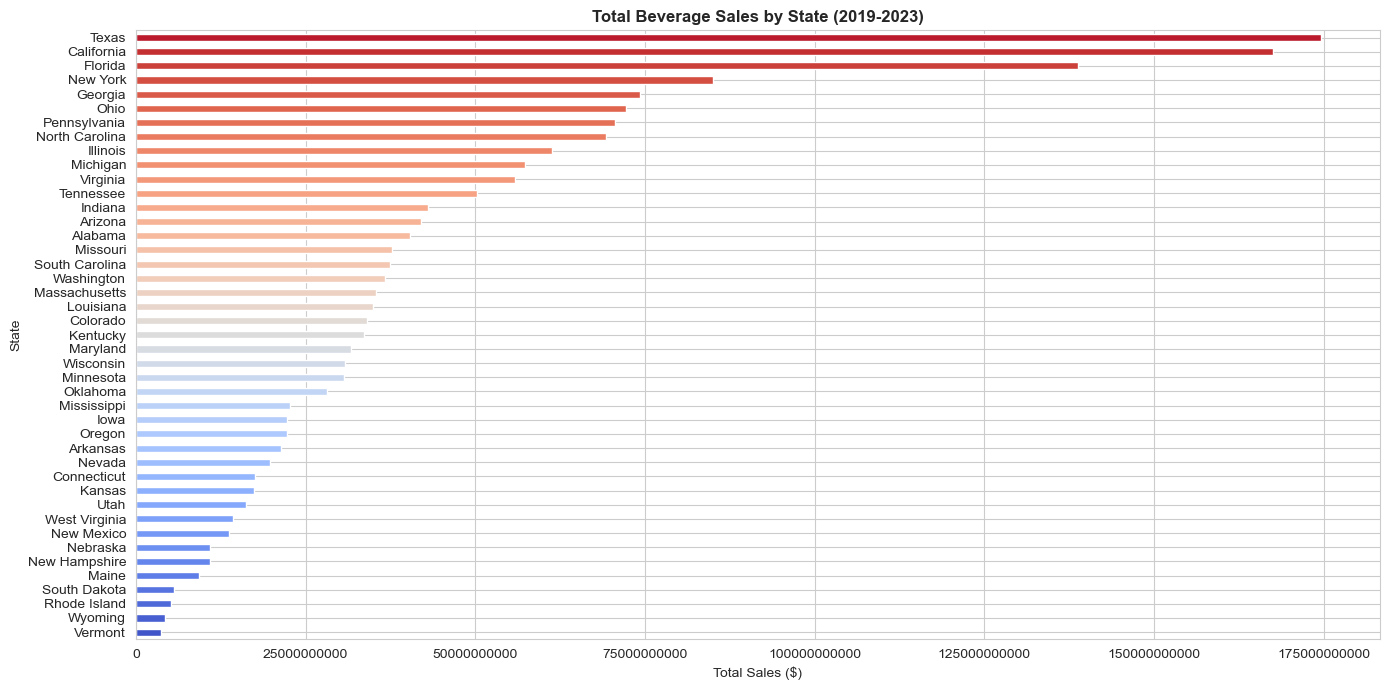

In [ ]:
fig, ax = plt.subplots(figsize=(14, 7))
df_pivot.sum().sort_values().plot(
    kind="barh", ax=ax, color=sns.color_palette("coolwarm", 43)
)
ax.set_xlabel("Total Sales ($)")
ax.set_title("Total Beverage Sales by State (2019-2023)", fontweight="bold")
ax.ticklabel_format(style="plain", axis="x")
plt.tight_layout()
plt.savefig(f"{OUTPUT}/eda_01_total_sales_by_state.png", dpi=150)
plt.show()

Sales Trends -> Top 5 & Bottom 5 States

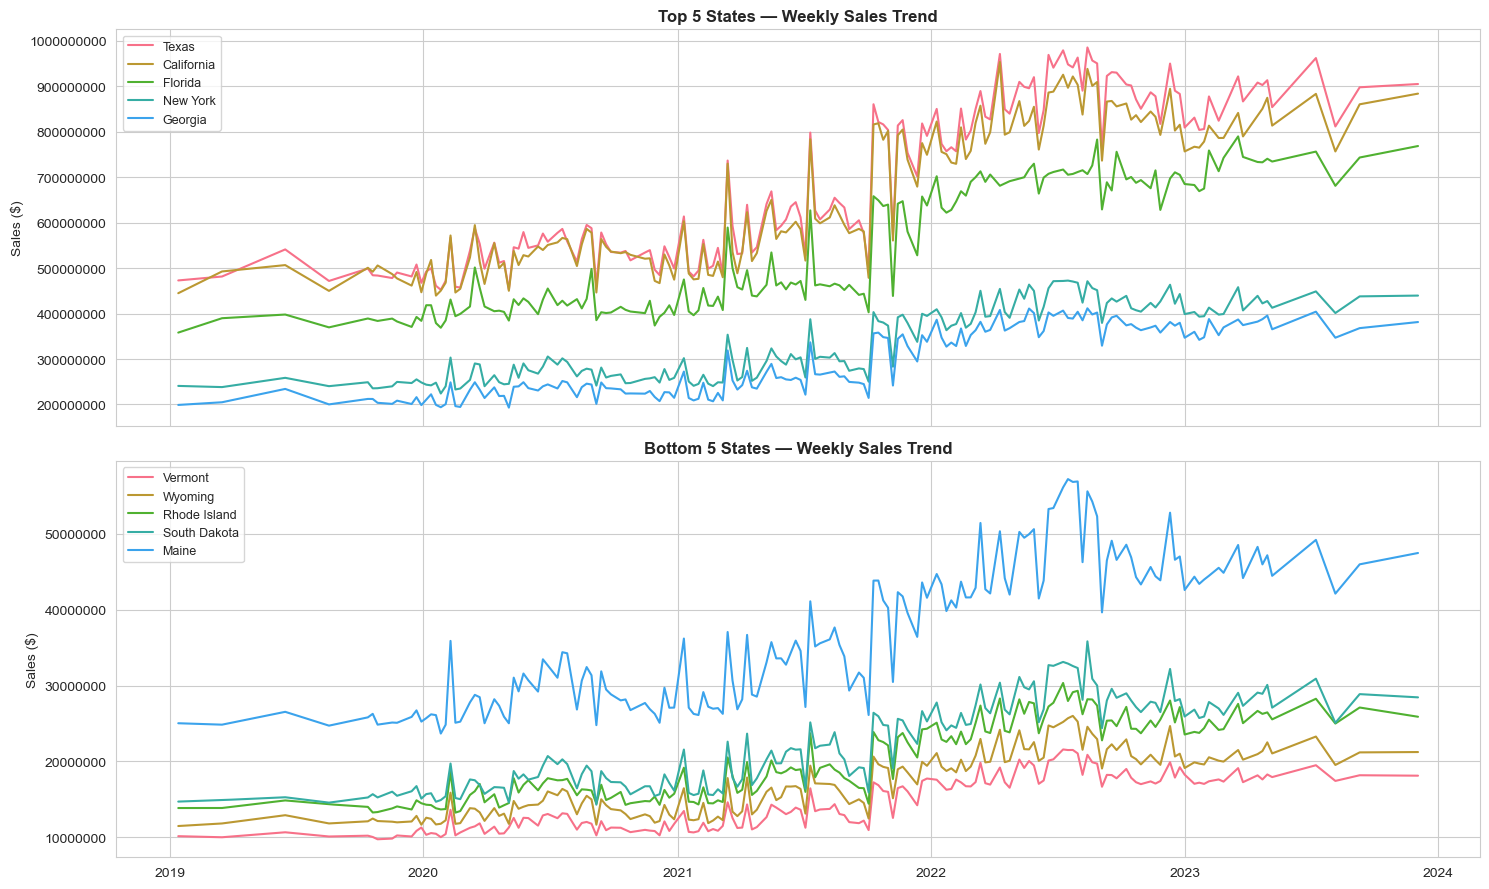

In [ ]:
top5 = df_pivot.sum().nlargest(5).index
bot5 = df_pivot.sum().nsmallest(5).index

fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=True)

for s in top5:
    axes[0].plot(df_pivot.index, df_pivot[s], label=s, lw=1.5)
axes[0].set_title("Top 5 States — Weekly Sales Trend", fontweight="bold")
axes[0].set_ylabel("Sales ($)")
axes[0].legend(fontsize=9)
axes[0].ticklabel_format(style="plain", axis="y")

for s in bot5:
    axes[1].plot(df_pivot.index, df_pivot[s], label=s, lw=1.5)
axes[1].set_title("Bottom 5 States — Weekly Sales Trend", fontweight="bold")
axes[1].set_ylabel("Sales ($)")
axes[1].legend(fontsize=9)
axes[1].ticklabel_format(style="plain", axis="y")

plt.tight_layout()
plt.savefig(f"{OUTPUT}/eda_02_trend_top_bottom.png", dpi=150)
plt.show()

Seasonality Heatmap
-> Average weekly sales by month for the top 10 states, reveals summer peaks and holiday spikes.

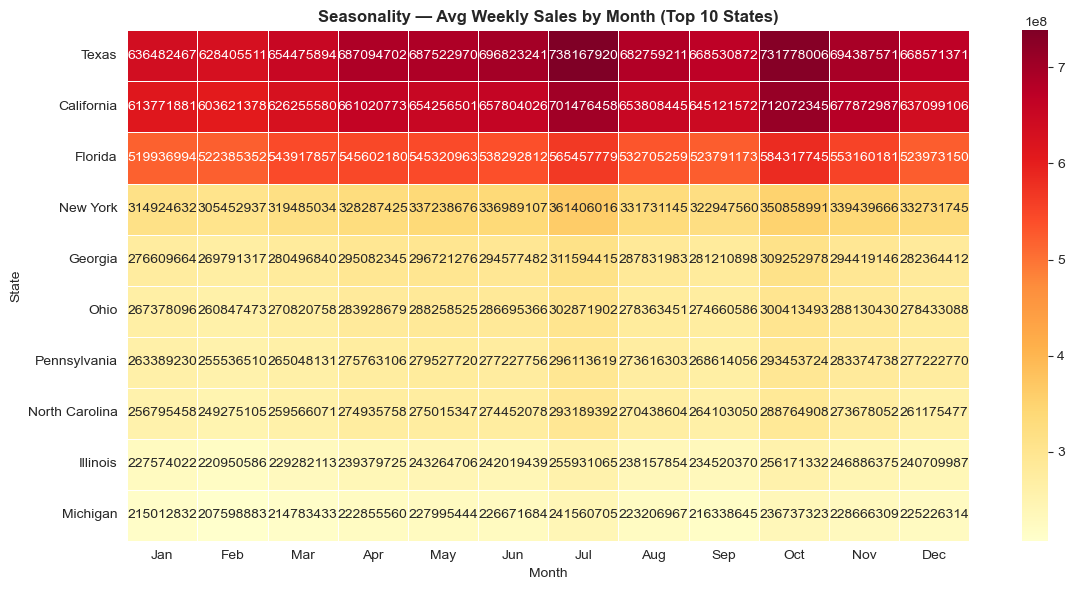

In [ ]:
top10 = df_pivot.sum().nlargest(10).index
monthly = df_pivot.copy()
monthly["Month"] = monthly.index.month
monthly_avg = monthly.groupby("Month")[top10].mean()

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(
    monthly_avg.T, annot=True, fmt=".0f", cmap="YlOrRd",
    ax=ax, linewidths=0.5
)
ax.set_xticklabels(
    ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
)
ax.set_title("Seasonality — Avg Weekly Sales by Month (Top 10 States)", fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUTPUT}/eda_03_seasonality_heatmap.png", dpi=150)
plt.show()

YOY Comparison
-> Overlay each year's weekly sales to see how the overall trend changes year to year.

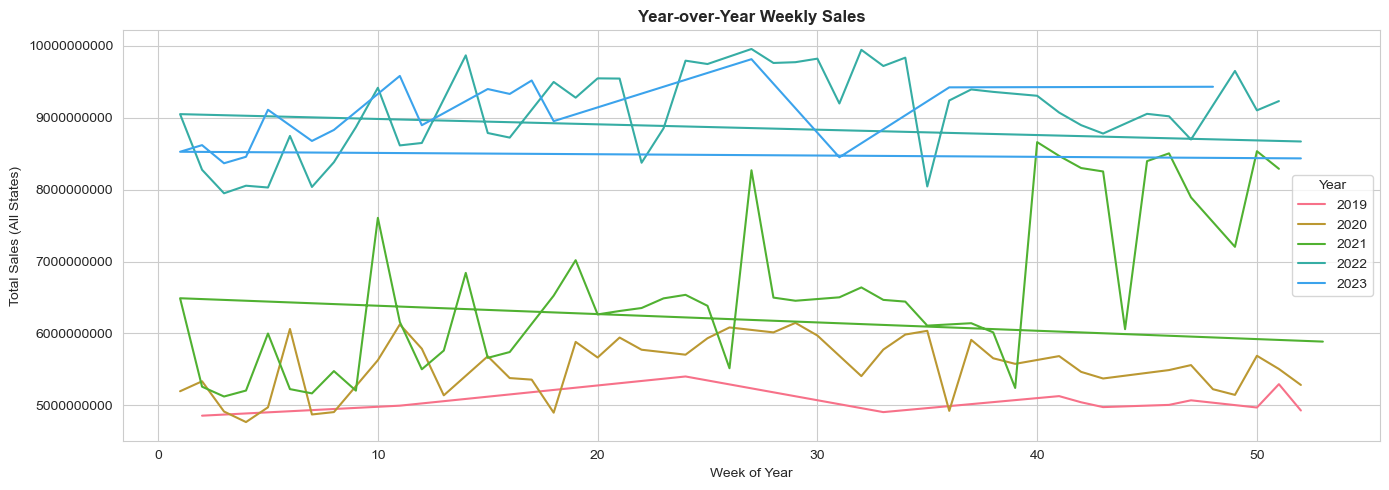

In [ ]:
total = df_pivot.sum(axis=1).to_frame("Total")
total["Year"] = total.index.year
total["Week"] = total.index.isocalendar().week.astype(int)

fig, ax = plt.subplots(figsize=(14, 5))
for yr in sorted(total["Year"].unique()):
    sub = total[total["Year"] == yr]
    ax.plot(sub["Week"], sub["Total"], label=str(yr), lw=1.5)

ax.set_xlabel("Week of Year")
ax.set_ylabel("Total Sales (All States)")
ax.set_title("Year-over-Year Weekly Sales", fontweight="bold")
ax.legend(title="Year")
ax.ticklabel_format(style="plain", axis="y")
plt.tight_layout()
plt.savefig(f"{OUTPUT}/eda_04_yoy.png", dpi=150)
plt.show()

Sales distribution by State

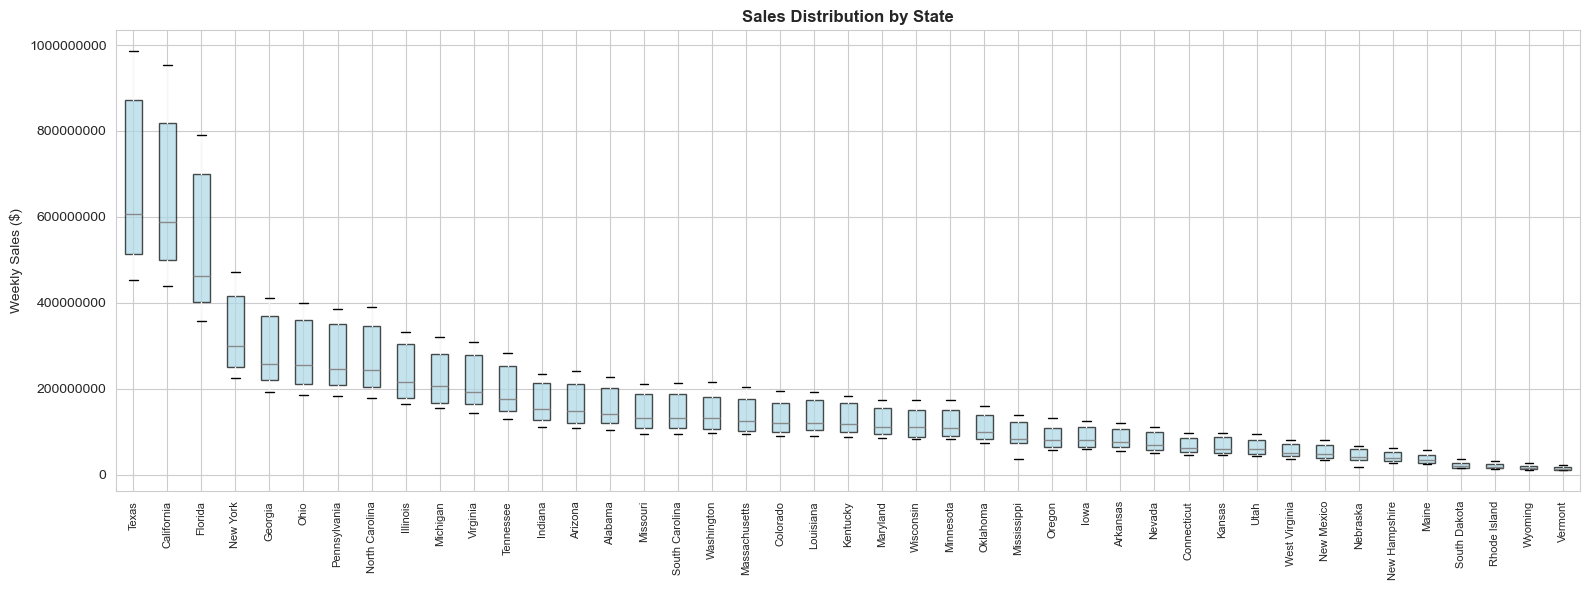

In [ ]:
order = df_pivot.median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(16, 6))
df_pivot[order].boxplot(
    ax=ax, vert=True, patch_artist=True,
    boxprops=dict(facecolor="lightblue", alpha=0.7)
)
ax.set_xticklabels(order, rotation=90, fontsize=8)
ax.set_ylabel("Weekly Sales ($)")
ax.set_title("Sales Distribution by State", fontweight="bold")
ax.ticklabel_format(style="plain", axis="y")
plt.tight_layout()
plt.savefig(f"{OUTPUT}/eda_05_boxplot.png", dpi=150)
plt.show()

State to State Correlation

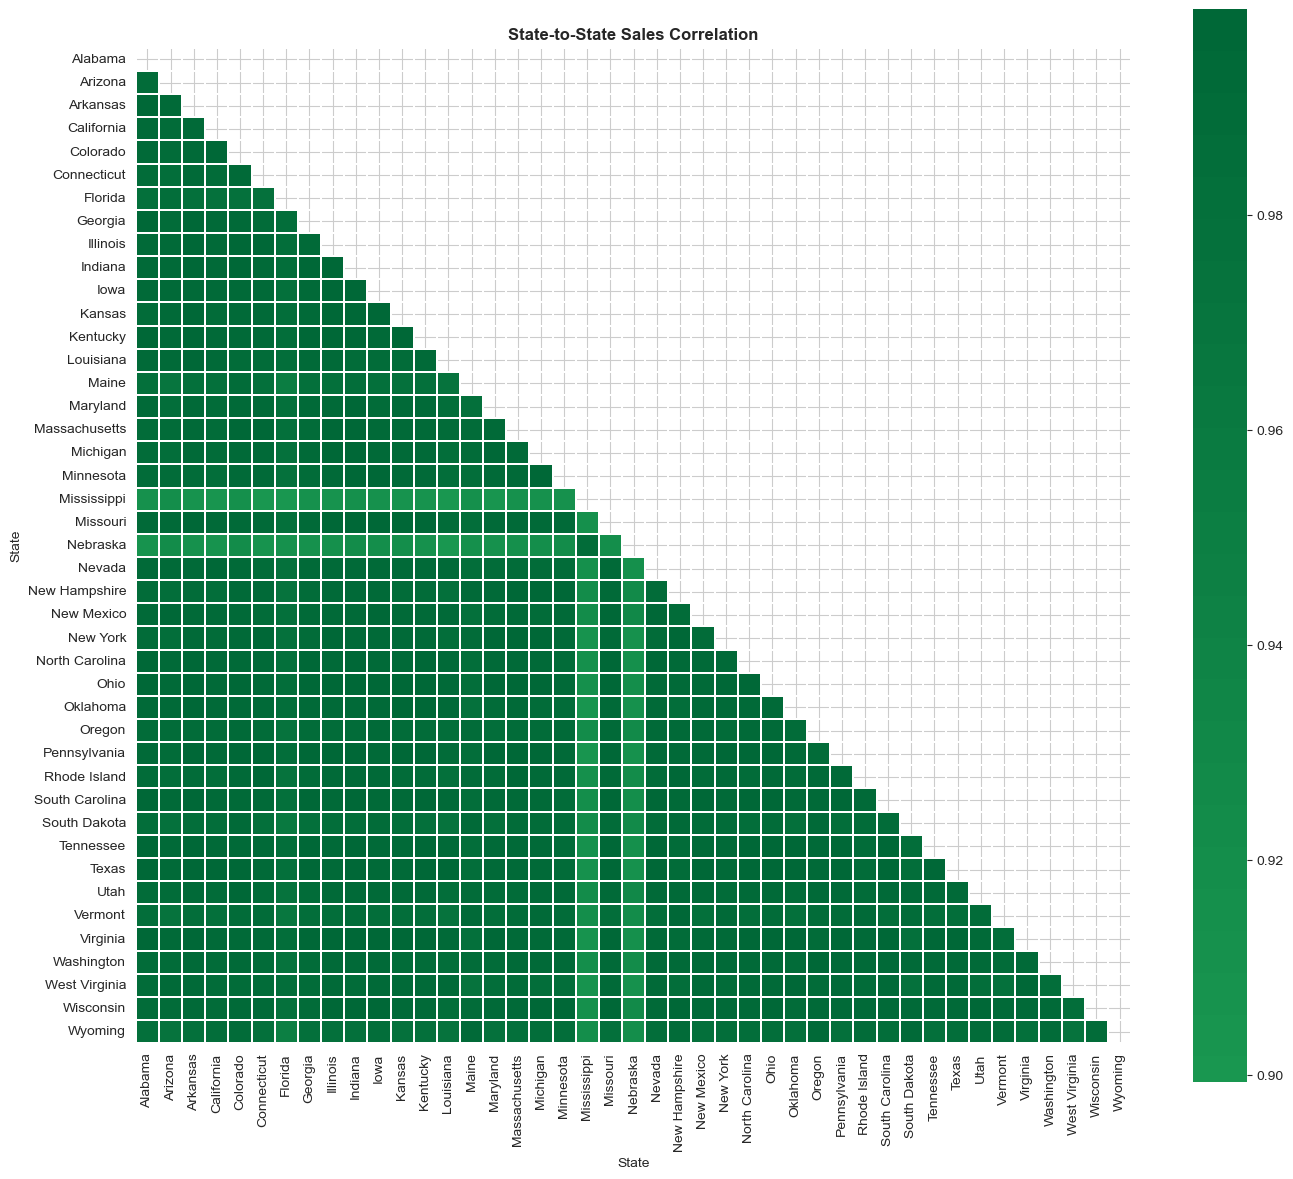

Top 10 correlated state pairs:
  Kentucky - Tennessee : 0.9991
  Indiana - Ohio : 0.9990
  North Carolina - South Carolina : 0.9987
  Alabama - Georgia : 0.9985
  Minnesota - Wisconsin : 0.9985
  Arkansas - Tennessee : 0.9985
  Indiana - Missouri : 0.9984
  Ohio - Pennsylvania : 0.9983
  Oregon - Washington : 0.9983
  Maryland - Pennsylvania : 0.9983


In [ ]:
# high correlation means they share similar trends.

corr = df_pivot.corr()

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))  # show only lower triangle
sns.heatmap(corr, mask=mask, cmap="RdYlGn", center=0.5, ax=ax,
            square=True, linewidths=0.3)
ax.set_title("State-to-State Sales Correlation", fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUTPUT}/eda_06_correlation.png", dpi=150)
plt.show()

# top 10 most correlated state pairs
pairs = corr.where(~mask).unstack().dropna()
pairs = pairs[pairs < 1.0].sort_values(ascending=False).head(10)
print("Top 10 correlated state pairs:")
for (s1, s2), v in pairs.items():
    print(f"  {s1} - {s2} : {v:.4f}")

Outlier Detection (IQR Method)

In [ ]:
Q1 = df_pivot.quantile(0.25)
Q3 = df_pivot.quantile(0.75)
IQR = Q3 - Q1

outliers = ((df_pivot < (Q1 - 1.5 * IQR)) | (df_pivot > (Q3 + 1.5 * IQR))).sum()
outliers = outliers[outliers > 0].sort_values(ascending=False)

print(f"States with outlier weeks ({outliers.sum()} total outlier points):")
print(outliers)

States with outlier weeks (0 total outlier points):
Series([], dtype: int64)


# Seasonal Decomposition (California)
Break California's sales into three components:
- Trend: the long-term direction
- Seasonal: the repeating yearly pattern
- Residual: what's left after removing trend and seasonality

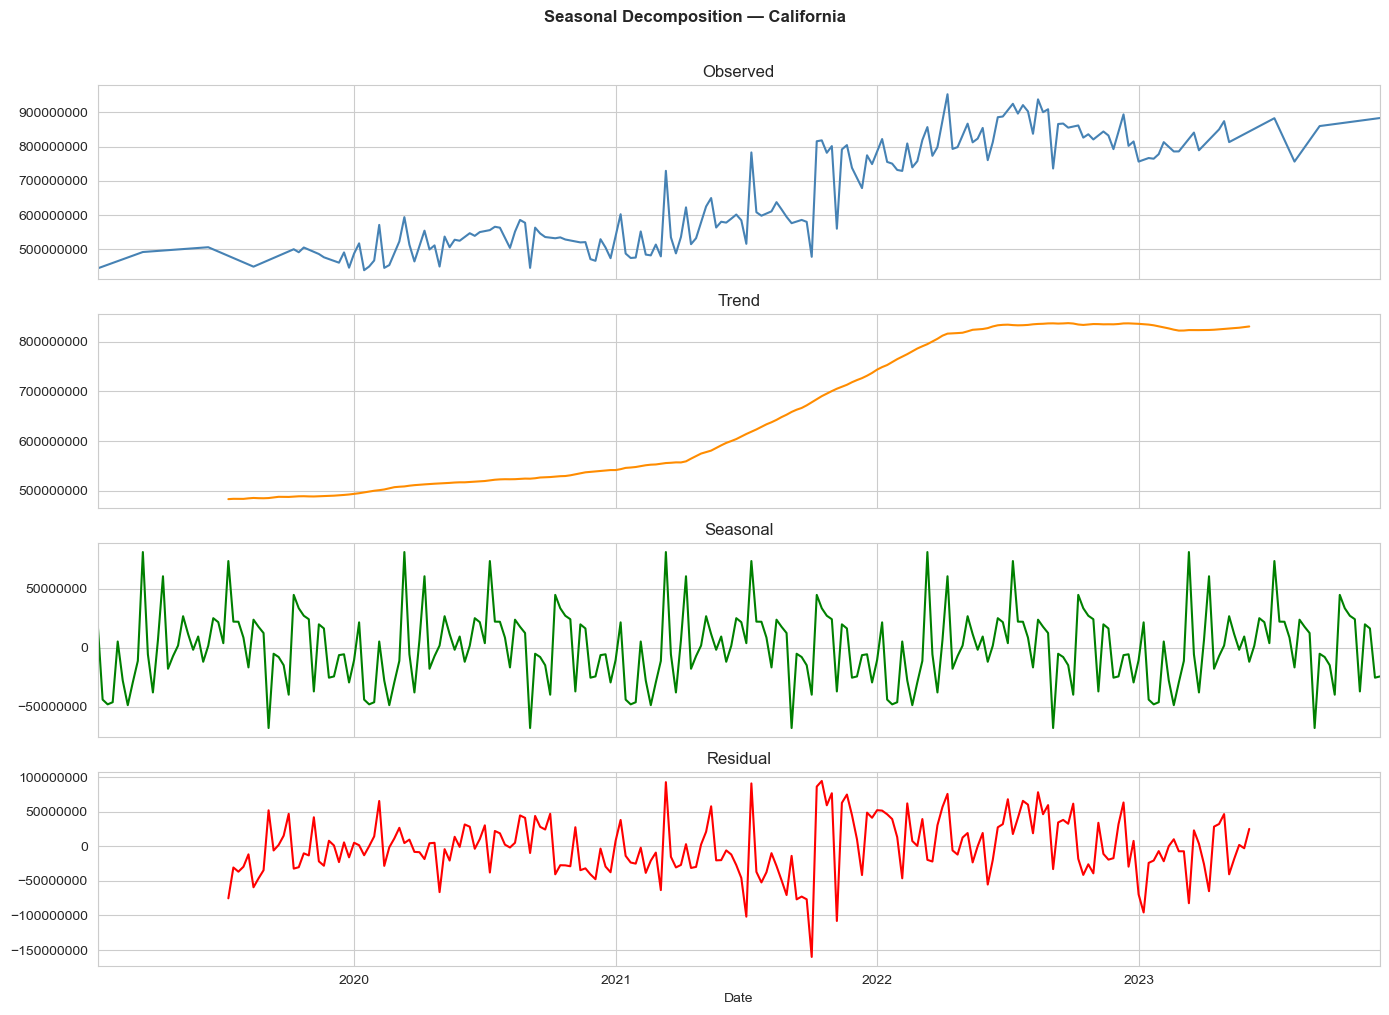

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

# period=52 because we have weekly data with yearly seasonality
result = seasonal_decompose(df_pivot["California"].dropna(), model="additive", period=52)

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
result.observed.plot(ax=axes[0], title="Observed", color="steelblue")
result.trend.plot(ax=axes[1], title="Trend", color="darkorange")
result.seasonal.plot(ax=axes[2], title="Seasonal", color="green")
result.resid.plot(ax=axes[3], title="Residual", color="red")

for ax in axes:
    ax.ticklabel_format(style="plain", axis="y")

fig.suptitle("Seasonal Decomposition — California", fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(f"{OUTPUT}/eda_07_decomposition.png", dpi=150, bbox_inches="tight")
plt.show()

Stationarity Test (ADF)
- p-value < 0.05 → the series is stationary (stable mean)
- p-value >= 0.05 → non-stationary (has a trend or shifting mean, needs differencing)

In [ ]:
from statsmodels.tsa.stattools import adfuller

adf = {}
for state in df_pivot.columns:
    stat, pval, *_ = adfuller(df_pivot[state].dropna(), autolag="AIC")
    adf[state] = {
        "ADF Statistic": round(stat, 4),
        "p-value": round(pval, 4),
        "Stationary": pval < 0.05
    }

adf_df = pd.DataFrame(adf).T
print(f"Stationary states    : {adf_df['Stationary'].sum()} / {len(adf_df)}")
print(f"Non-stationary states: {(~adf_df['Stationary']).sum()} / {len(adf_df)}")
adf_df

Stationary states    : False / 43
Non-stationary states: True / 43


,ADF Statistic,p-value,Stationary
Alabama,-0.6498,0.8593,False
Arizona,-0.3321,0.9208,False
Arkansas,-0.5381,0.8844,False
California,-0.2881,0.9272,False
Colorado,-0.5519,0.8815,False
Connecticut,-0.6237,0.8655,False
Florida,-0.4179,0.9071,False
Georgia,-0.6035,0.8702,False
Illinois,-0.3696,0.9151,False
Indiana,-0.5437,0.8832,False


## EDA Abstract

- **43 US states**, weekly data from Jan 2019 to Dec 2023 (~256 weeks per state)
- **Top revenue states**: California, Texas, Florida, New York
- **Seasonality**: sales peak in Jun-Aug (summer) with holiday spikes in Nov-Dec
- **Trend**: overall upward trend across most states
- **Correlation**: most states are highly correlated (move together)
- **Stationarity**: many states are non-stationary, will need differencing

# Feature Engineering

Time Feature

In [ ]:
feat = df.copy()
feat.sort_values(["State", "Date"], inplace=True)

# calendar features
feat["year"]       = feat["Date"].dt.year
feat["month"]      = feat["Date"].dt.month
feat["week"]       = feat["Date"].dt.isocalendar().week.astype(int)
feat["day_of_week"] = feat["Date"].dt.dayofweek   # 0 = Monday, 6 = Sunday
feat["quarter"]    = feat["Date"].dt.quarter

# sin/cos encoding — makes December close to January (cyclical, not a cliff)
feat["month_sin"] = np.sin(2 * np.pi * feat["month"] / 12)
feat["month_cos"] = np.cos(2 * np.pi * feat["month"] / 12)
feat["week_sin"]  = np.sin(2 * np.pi * feat["week"] / 52)
feat["week_cos"]  = np.cos(2 * np.pi * feat["week"] / 52)

print("Time features created")
feat[["Date","State","year","month","week","quarter","month_sin"]].head()

Time features created


,Date,State,year,month,week,quarter,month_sin
0,2019-01-13,Alabama,2019,1,2,1,0.500000
1,2019-01-20,Alabama,2019,1,3,1,0.500000
2,2019-01-27,Alabama,2019,1,4,1,0.500000
3,2019-02-03,Alabama,2019,2,5,1,0.866025
4,2019-02-10,Alabama,2019,2,6,1,0.866025


Lag Feature

In [ ]:
# shift within each state (no leakage)
lags = [1, 7, 30]  # in weeks

for lag in lags:
    feat[f"lag_{lag}"] = feat.groupby("State")["Total"].shift(lag)

print(f"Lag features created: {[f'lag_{l}' for l in lags]}")

Lag features created: ['lag_1', 'lag_7', 'lag_30']


Rolling Window Statistics

- **rmean_4**: average of the last 4 weeks (short-term trend)
- **rmean_52**: average of the last 52 weeks (yearly trend)
- **rstd_***: how volatile the sales were over that window
- **rmin/rmax_13**: lowest/highest sales in the last quarter



In [ ]:
windows = [4, 8, 13, 26, 52]  # weeks

for w in windows:
    # shift(1) ensures we only use past data (no leakage)
    feat[f"rmean_{w}"] = (
        feat.groupby("State")["Total"]
        .transform(lambda x: x.shift(1).rolling(w, min_periods=1).mean())
    )
    feat[f"rstd_{w}"] = (
        feat.groupby("State")["Total"]
        .transform(lambda x: x.shift(1).rolling(w, min_periods=1).std())
    )

# quarterly (13-week) min and max — useful for detecting unusual highs/lows
feat["rmin_13"] = feat.groupby("State")["Total"].transform(
    lambda x: x.shift(1).rolling(13, min_periods=1).min()
)
feat["rmax_13"] = feat.groupby("State")["Total"].transform(
    lambda x: x.shift(1).rolling(13, min_periods=1).max()
)

print(f"Rolling features created for windows: {windows}")

Rolling features created for windows: [4, 8, 13, 26, 52]


Expanding Mean & State Encoding

In [ ]:
# expanding mean: cumulative average of ALL past weeks (grows over time)
# shift(1) ensures we don't include the current week's value
feat["expanding_mean"] = (
    feat.groupby("State")["Total"]
    .transform(lambda x: x.shift(1).expanding(min_periods=1).mean())
)

# convert state names to numeric codes so tree models can use them
from sklearn.preprocessing import LabelEncoder
feat["state_code"] = LabelEncoder().fit_transform(feat["State"])

print("Expanding mean + state encoding created")

Expanding mean + state encoding created


Holiday Flag

In [ ]:
# approximate US holidays (month, day)
HOLIDAYS = [
    (1, 1),    # New Year's Day
    (1, 20),   # MLK Day (approx)
    (2, 17),   # Presidents' Day (approx)
    (5, 26),   # Memorial Day (approx)
    (7, 4),    # Independence Day
    (9, 1),    # Labor Day (approx)
    (10, 13),  # Columbus Day (approx)
    (11, 11),  # Veterans Day
    (11, 27),  # Thanksgiving (approx)
    (12, 25),  # Christmas
]

def near_holiday(date, window=3):
    """Returns 1 if date is within `window` days of any US holiday."""
    for m, d in HOLIDAYS:
        try:
            h = pd.Timestamp(year=date.year, month=m, day=d)
            if abs((date - h).days) <= window:
                return 1
        except ValueError:
            pass  # skip invalid dates like Feb 29 in non-leap years
    return 0

feat["is_holiday"] = feat["Date"].apply(near_holiday)
print(f"Holiday weeks flagged: {feat['is_holiday'].sum()}")

Holiday weeks flagged: 2021


Growth Rate

- **pct_wow**: week-over-week change
- **pct_mom**: month-over-month (4 weeks)
- **pct_yoy**: year-over-year (52 weeks)

In [ ]:
# pct_change naturally only looks backwards — no leakage
feat["pct_wow"] = feat.groupby("State")["Total"].pct_change(1)   # week-over-week
feat["pct_mom"] = feat.groupby("State")["Total"].pct_change(4)   # month-over-month
feat["pct_yoy"] = feat.groupby("State")["Total"].pct_change(52)  # year-over-year

print("Growth rates created: pct_wow, pct_mom, pct_yoy")

Growth rates created: pct_wow, pct_mom, pct_yoy


Feature Abstract

In [ ]:
feature_cols = [c for c in feat.columns if c not in ["Date", "State", "Total"]]

print(f"Total features: {len(feature_cols)}")
print(f"Dataset shape : {feat.shape}")
print(f"\nFeature list:")
for c in feature_cols:
    print(f"  {c:20s} | nulls: {feat[c].isnull().sum():5d} | type: {feat[c].dtype}")

Total features: 30
Dataset shape : (11008, 33)

Feature list:
  year                 | nulls:     0 | type: int32
  month                | nulls:     0 | type: int32
  week                 | nulls:     0 | type: int64
  day_of_week          | nulls:     0 | type: int32
  quarter              | nulls:     0 | type: int32
  month_sin            | nulls:     0 | type: float64
  month_cos            | nulls:     0 | type: float64
  week_sin             | nulls:     0 | type: float64
  week_cos             | nulls:     0 | type: float64
  lag_1                | nulls:    43 | type: float64
  lag_7                | nulls:   301 | type: float64
  lag_30               | nulls:  1290 | type: float64
  rmean_4              | nulls:    43 | type: float64
  rstd_4               | nulls:    86 | type: float64
  rmean_8              | nulls:    43 | type: float64
  rstd_8               | nulls:    86 | type: float64
  rmean_13             | nulls:    43 | type: float64
  rstd_13              | nulls

Save Feature Dataset

In [ ]:
# full version (includes NaN rows from lag/rolling warm-up period)
feat.to_csv(f"{OUTPUT}/features_full.csv", index=False)
print(f"Saved: features_full.csv   ({feat.shape})")

# clean version — drop rows with NaN (warm-up rows), ready for model training
feat_clean = feat.dropna()
feat_clean.to_csv(f"{OUTPUT}/features_clean.csv", index=False)
print(f"Saved: features_clean.csv  ({feat_clean.shape})")

Saved: features_full.csv   ((11008, 33))
Saved: features_clean.csv  ((8772, 33))


# Multi-model Traning and Comparison

We train **7 models** across three categories:
- **Time-series models**: SARIMA, Prophet -> these work on the raw sales series directly
- **Tree-based ML models**: XGBoost, Random Forest, LightGBM, Gradient Boosting -> use all engineered features
- **Deep learning**: LSTM -> uses engineered features with scaled inputs

Each model is trained **separately for each state** (43 states), and we compare their accuracy.

Setup


In [ ]:
import pickle
import time
from collections import OrderedDict
from sklearn.metrics import mean_absolute_error, mean_squared_error

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"  # hide TensorFlow info messages

MODEL_DIR = f"{OUTPUT}/models"
os.makedirs(MODEL_DIR, exist_ok=True)

print("Training setup ready")

Training setup ready


Load Preprocessed Data

In [ ]:
feat = pd.read_csv(f"{OUTPUT}/features_clean.csv", parse_dates=["Date"])

states = feat["State"].unique().tolist()
print(f"States : {len(states)}")
print(f"Shape  : {feat.shape}")
feat.head()

States : 43
Shape  : (8772, 33)


,Date,State,Total,year,month,week,day_of_week,quarter,month_sin,month_cos,...,rmean_52,rstd_52,rmin_13,rmax_13,expanding_mean,state_code,is_holiday,pct_wow,pct_mom,pct_yoy
0,2020-01-12,Alabama,120522113.9,2020,1,2,6,1,0.500000,0.866025,...,1.151249e+08,5.831631e+06,106949922.2,117357599.3,1.151249e+08,0,0,0.033181,0.110512,0.099915
1,2020-01-19,Alabama,105904865.6,2020,1,3,6,1,0.500000,0.866025,...,1.153354e+08,5.824925e+06,106949922.2,120522113.9,1.152267e+08,0,1,-0.121283,-0.091270,-0.036042
2,2020-01-26,Alabama,106265736.6,2020,1,4,6,1,0.500000,0.866025,...,1.152593e+08,5.922905e+06,105904865.6,120522113.9,1.150541e+08,0,0,0.003408,-0.006397,-0.035309
3,2020-02-02,Alabama,108358279.6,2020,2,5,6,1,0.866025,0.500000,...,1.151845e+08,6.012507e+06,105904865.6,120522113.9,1.148943e+08,0,0,0.019692,-0.071094,-0.018900
4,2020-02-09,Alabama,131945461.1,2020,2,6,6,1,0.866025,0.500000,...,1.151443e+08,6.051607e+06,105904865.6,120522113.9,1.147776e+08,0,0,0.217678,0.094782,0.191529


Evaluation Function

- **MAE** (Mean Absolute Error): average dollar amount the prediction is off
- **RMSE** (Root Mean Squared Error): like MAE but penalizes large errors more
- **MAPE** (Mean Absolute Percentage Error): error as a percentage of actual sales

In [ ]:
def evaluate(y_true, y_pred):
    """Compute MAE, RMSE, and MAPE between actual and predicted values."""
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)

    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    # skip zero values to avoid dividing by zero
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

    return {"MAE": round(mae, 2), "RMSE": round(rmse, 2), "MAPE": round(mape, 2)}

Train-Test Split

In [ ]:
feat = feat.sort_values(["State", "Date"]).reset_index(drop=True)

# find the date that marks the 80% point
dates = sorted(feat["Date"].unique())
cutoff_idx = int(len(dates) * 0.8)
cutoff_date = dates[cutoff_idx]

# everything before the cutoff = training, everything after = testing
train_df = feat[feat["Date"] < cutoff_date].copy()
test_df  = feat[feat["Date"] >= cutoff_date].copy()

print(f"Cutoff date : {cutoff_date}")
print(f"Train shape : {train_df.shape}  ({len(train_df) / len(feat) * 100:.0f}%)")
print(f"Test shape  : {test_df.shape}  ({len(test_df) / len(feat) * 100:.0f}%)")

Cutoff date : 2023-02-26 00:00:00
Train shape : (7009, 33)  (80%)
Test shape  : (1763, 33)  (20%)


Define Feature Columns

SARIMA and Prophet use the raw time series (no features needed).
All other models use the full feature set.

In [ ]:
# lag features — the strongest predictors for tree models
lag_features = ["lag_1", "lag_7", "lag_30"]

# rolling window statistics — capture recent trends and volatility
rolling_features = [
    "rmean_4", "rmean_8", "rmean_13", "rmean_26", "rmean_52",
    "rstd_4", "rstd_8", "rstd_13", "rstd_26", "rstd_52",
    "rmin_13", "rmax_13", "expanding_mean",
]

# time-based features — capture yearly and weekly patterns
time_features = [
    "year", "month", "week", "day_of_week", "quarter",
    "month_sin", "month_cos", "week_sin", "week_cos",
]

# other engineered features
other_features = ["state_code", "is_holiday", "pct_wow", "pct_mom", "pct_yoy"]

# combine all
feature_cols = lag_features + rolling_features + time_features + other_features
feature_cols = [c for c in feature_cols if c in feat.columns]

print(f"Total features: {len(feature_cols)}")
print(f"  Lag     : {len(lag_features)}")
print(f"  Rolling : {len(rolling_features)}")
print(f"  Time    : {len(time_features)}")
print(f"  Other   : {len(other_features)}")

Total features: 30
  Lag     : 3
  Rolling : 13
  Time    : 9
  Other   : 5


Model Definitions

In [ ]:
# 1. SARIMA 
# Works on the raw sales series. Uses differencing to handle trends.
# order=(1,1,1): 1 autoregressive term, 1 differencing, 1 moving average
# seasonal_order=(0,1,0,52): yearly seasonal differencing (52 weeks)
def train_sarima(tr, te, fcols):
    from statsmodels.tsa.statespace.sarimax import SARIMAX

    y_train = tr.sort_values("Date")["Total"].values
    model = SARIMAX(
        y_train,
        order=(1, 1, 1),
        seasonal_order=(0, 1, 0, 52),
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    fit = model.fit(disp=False, maxiter=300)
    preds = fit.forecast(steps=len(te))
    return preds, None


# 2. Prophet 
# Facebook's time-series model. Automatically detects yearly seasonality.
def train_prophet(tr, te, fcols):
    import logging
    logging.getLogger("prophet").setLevel(logging.WARNING)
    logging.getLogger("cmdstanpy").setLevel(logging.WARNING)
    from prophet import Prophet

    # Prophet requires columns named 'ds' (date) and 'y' (target)
    train_p = tr[["Date", "Total"]].rename(columns={"Date": "ds", "Total": "y"})
    test_p  = te[["Date"]].rename(columns={"Date": "ds"})

    m = Prophet(yearly_seasonality=True, weekly_seasonality=False,
                daily_seasonality=False)
    m.fit(train_p)
    fcast = m.predict(test_p)
    return fcast["yhat"].values, None


# 3. XGBoost 
# Gradient-boosted trees with built-in GridSearchCV for basic tuning.
# Uses TimeSeriesSplit (not random) to respect time order during cross-validation.
def train_xgboost(tr, te, fcols):
    from xgboost import XGBRegressor
    from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

    X_tr, y_tr = tr[fcols], tr["Total"]
    X_te       = te[fcols]

    param_grid = {
        "n_estimators": [100, 200, 300],
        "max_depth": [3, 5, 7],
        "learning_rate": [0.01, 0.05, 0.1],
        "subsample": [0.8, 1.0],
    }

    grid = GridSearchCV(
        XGBRegressor(random_state=42, verbosity=0),
        param_grid,
        scoring="neg_root_mean_squared_error",
        cv=TimeSeriesSplit(n_splits=3),
        n_jobs=-1,
    )
    grid.fit(X_tr, y_tr)
    best = grid.best_estimator_
    return best.predict(X_te), best


# 4. LSTM 
# Neural network that can learn patterns in sequences.
# We scale inputs to [0, 1] range — important for neural networks.
# Scalers are fit on TRAINING data only (no leakage from test data).
def train_lstm(tr, te, fcols):
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense, Dropout
    from tensorflow.keras.callbacks import EarlyStopping
    from sklearn.preprocessing import MinMaxScaler

    X_tr = tr[fcols].values
    y_tr = tr["Total"].values.reshape(-1, 1)
    X_te = te[fcols].values

    # fit scalers on training data only
    sc_x = MinMaxScaler().fit(X_tr)
    sc_y = MinMaxScaler().fit(y_tr)

    # LSTM expects 3D input: (samples, timesteps, features)
    X_tr_s = sc_x.transform(X_tr).reshape(-1, 1, len(fcols))
    X_te_s = sc_x.transform(X_te).reshape(-1, 1, len(fcols))
    y_tr_s = sc_y.transform(y_tr).ravel()

    # 2-layer LSTM with dropout to prevent overfitting
    model = Sequential([
        LSTM(64, input_shape=(1, len(fcols)), return_sequences=True),
        Dropout(0.2),
        LSTM(32),
        Dropout(0.2),
        Dense(1),
    ])
    model.compile(optimizer="adam", loss="mse")

    # stop training early if validation loss stops improving
    es = EarlyStopping(patience=10, restore_best_weights=True, verbose=0)
    model.fit(X_tr_s, y_tr_s, epochs=50, batch_size=16,
              validation_split=0.1, callbacks=[es], verbose=0)

    # predict and convert back to original scale
    preds_s = model.predict(X_te_s, verbose=0).ravel()
    preds = sc_y.inverse_transform(preds_s.reshape(-1, 1)).ravel()
    return preds, None


# 5. Random Forest 
# Ensemble of many decision trees. Each tree sees a random subset of data.
def train_rf(tr, te, fcols):
    from sklearn.ensemble import RandomForestRegressor

    X_tr, y_tr = tr[fcols], tr["Total"]
    X_te       = te[fcols]

    model = RandomForestRegressor(
        n_estimators=200, max_depth=10, min_samples_leaf=4,
        random_state=42, n_jobs=-1,
    )
    model.fit(X_tr, y_tr)
    return model.predict(X_te), model


# 6. LightGBM 
# Fast gradient boosting that grows trees leaf-by-leaf (instead of level-by-level).
def train_lgbm(tr, te, fcols):
    import lightgbm as lgb

    X_tr, y_tr = tr[fcols], tr["Total"]
    X_te       = te[fcols]

    model = lgb.LGBMRegressor(
        n_estimators=200, max_depth=7, learning_rate=0.05,
        subsample=0.8, random_state=42, verbose=-1,
    )
    model.fit(X_tr, y_tr)
    return model.predict(X_te), model


# 7. Gradient Boosting 
# Sklearn's classic boosting — builds trees one at a time, each fixing the previous errors.
def train_gb(tr, te, fcols):
    from sklearn.ensemble import GradientBoostingRegressor

    X_tr, y_tr = tr[fcols], tr["Total"]
    X_te       = te[fcols]

    model = GradientBoostingRegressor(
        n_estimators=200, max_depth=5, learning_rate=0.05,
        subsample=0.8, random_state=42,
    )
    model.fit(X_tr, y_tr)
    return model.predict(X_te), model


# register all models in order
MODELS = OrderedDict([
    ("SARIMA",             train_sarima),
    ("Prophet",            train_prophet),
    ("XGBoost",            train_xgboost),
    ("LSTM",               train_lstm),
    ("Random Forest",      train_rf),
    ("LightGBM",           train_lgbm),
    ("Gradient Boosting",  train_gb),
])

print(f"Registered {len(MODELS)} models: {list(MODELS.keys())}")

Registered 7 models: ['SARIMA', 'Prophet', 'XGBoost', 'LSTM', 'Random Forest', 'LightGBM', 'Gradient Boosting']


Train All Models


In [ ]:
%pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [ ]:
all_results = []
best_models = {}  # stores fitted model objects: (model_name, state) -> model

sep = "=" * 60

for model_name, train_fn in MODELS.items():
    print(f"\n{sep}")
    print(f"  {model_name}")
    print(f"{sep}")

    t0 = time.time()
    ok, fail = 0, 0

    for state in states:
        tr = train_df[train_df["State"] == state]
        te = test_df[test_df["State"] == state]

        # skip states with too few training rows
        if len(tr) < 10 or len(te) == 0:
            continue

        try:
            preds, model_obj = train_fn(tr, te, feature_cols)
            metrics = evaluate(te["Total"].values, preds)
            metrics["model"] = model_name
            metrics["state"] = state
            all_results.append(metrics)

            if model_obj is not None:
                best_models[(model_name, state)] = model_obj

            ok += 1

        except Exception as e:
            print(f"  {state}: FAILED - {str(e)[:80]}")
            fail += 1

    elapsed = time.time() - t0
    print(f"  Done: {ok} ok / {fail} failed  ({elapsed:.1f}s)")

print(f"\nTotal results collected: {len(all_results)}")


  SARIMA
  Done: 43 ok / 0 failed  (75.3s)

  Prophet
  Done: 43 ok / 0 failed  (15.1s)

  XGBoost
  Done: 43 ok / 0 failed  (197.1s)

  LSTM
  Done: 43 ok / 0 failed  (811.4s)

  Random Forest
  Done: 43 ok / 0 failed  (50.6s)

  LightGBM
  Alabama: FAILED - No module named 'lightgbm'
  Arizona: FAILED - No module named 'lightgbm'
  Arkansas: FAILED - No module named 'lightgbm'
  California: FAILED - No module named 'lightgbm'
  Colorado: FAILED - No module named 'lightgbm'
  Connecticut: FAILED - No module named 'lightgbm'
  Florida: FAILED - No module named 'lightgbm'
  Georgia: FAILED - No module named 'lightgbm'
  Illinois: FAILED - No module named 'lightgbm'
  Indiana: FAILED - No module named 'lightgbm'
  Iowa: FAILED - No module named 'lightgbm'
  Kansas: FAILED - No module named 'lightgbm'
  Kentucky: FAILED - No module named 'lightgbm'
  Louisiana: FAILED - No module named 'lightgbm'
  Maine: FAILED - No module named 'lightgbm'
  Maryland: FAILED - No module named 'lightgbm'

Result -> Average Metrics Per Model

In [ ]:
results_df = pd.DataFrame(all_results)

# average across all states, sorted by RMSE (lower = better)
comparison = (
    results_df.groupby("model")[["MAE", "RMSE", "MAPE"]]
    .mean()
    .round(2)
    .sort_values("RMSE")
)

print("Average Metrics Across All States (sorted by RMSE):")
comparison

Average Metrics Across All States (sorted by RMSE):


,MAE,RMSE,MAPE
model,,,
Gradient Boosting,4248644.09,5097182.36,2.10
XGBoost,4916636.81,6003564.60,2.19
Random Forest,5293508.91,6251311.58,2.61
LSTM,10266805.63,11552120.56,4.92
Prophet,11047268.59,13343775.18,5.37
SARIMA,14159835.84,18045648.34,6.98


In [ ]:
# detailed breakdown per model
for model_name in MODELS.keys():
    sub = results_df[results_df["model"] == model_name]
    if sub.empty:
        print(f"\n{model_name}: NO RESULTS")
        continue

    best_st  = sub.loc[sub["RMSE"].idxmin(), "state"]
    worst_st = sub.loc[sub["RMSE"].idxmax(), "state"]

    print(f"\n{model_name}")
    print(f"  States trained : {len(sub)}")
    print(f"  Avg MAE        : {sub['MAE'].mean():.2f}")
    print(f"  Avg RMSE       : {sub['RMSE'].mean():.2f}")
    print(f"  Avg MAPE       : {sub['MAPE'].mean():.2f}%")
    print(f"  Best state     : {best_st} (RMSE={sub['RMSE'].min():.2f})")
    print(f"  Worst state    : {worst_st} (RMSE={sub['RMSE'].max():.2f})")


SARIMA
  States trained : 43
  Avg MAE        : 14159835.84
  Avg RMSE       : 18045648.34
  Avg MAPE       : 6.98%
  Best state     : Vermont (RMSE=1707544.25)
  Worst state    : Texas (RMSE=76475023.74)

Prophet
  States trained : 43
  Avg MAE        : 11047268.59
  Avg RMSE       : 13343775.18
  Avg MAPE       : 5.37%
  Best state     : Vermont (RMSE=885736.25)
  Worst state    : Texas (RMSE=72409827.51)

XGBoost
  States trained : 43
  Avg MAE        : 4916636.81
  Avg RMSE       : 6003564.60
  Avg MAPE       : 2.19%
  Best state     : Wyoming (RMSE=516632.36)
  Worst state    : Florida (RMSE=37769929.14)

LSTM
  States trained : 43
  Avg MAE        : 10266805.63
  Avg RMSE       : 11552120.56
  Avg MAPE       : 4.92%
  Best state     : Wyoming (RMSE=752580.21)
  Worst state    : Texas (RMSE=62154734.33)

Random Forest
  States trained : 43
  Avg MAE        : 5293508.91
  Avg RMSE       : 6251311.58
  Avg MAPE       : 2.61%
  Best state     : Vermont (RMSE=757643.98)
  Worst state

Comparison Plot

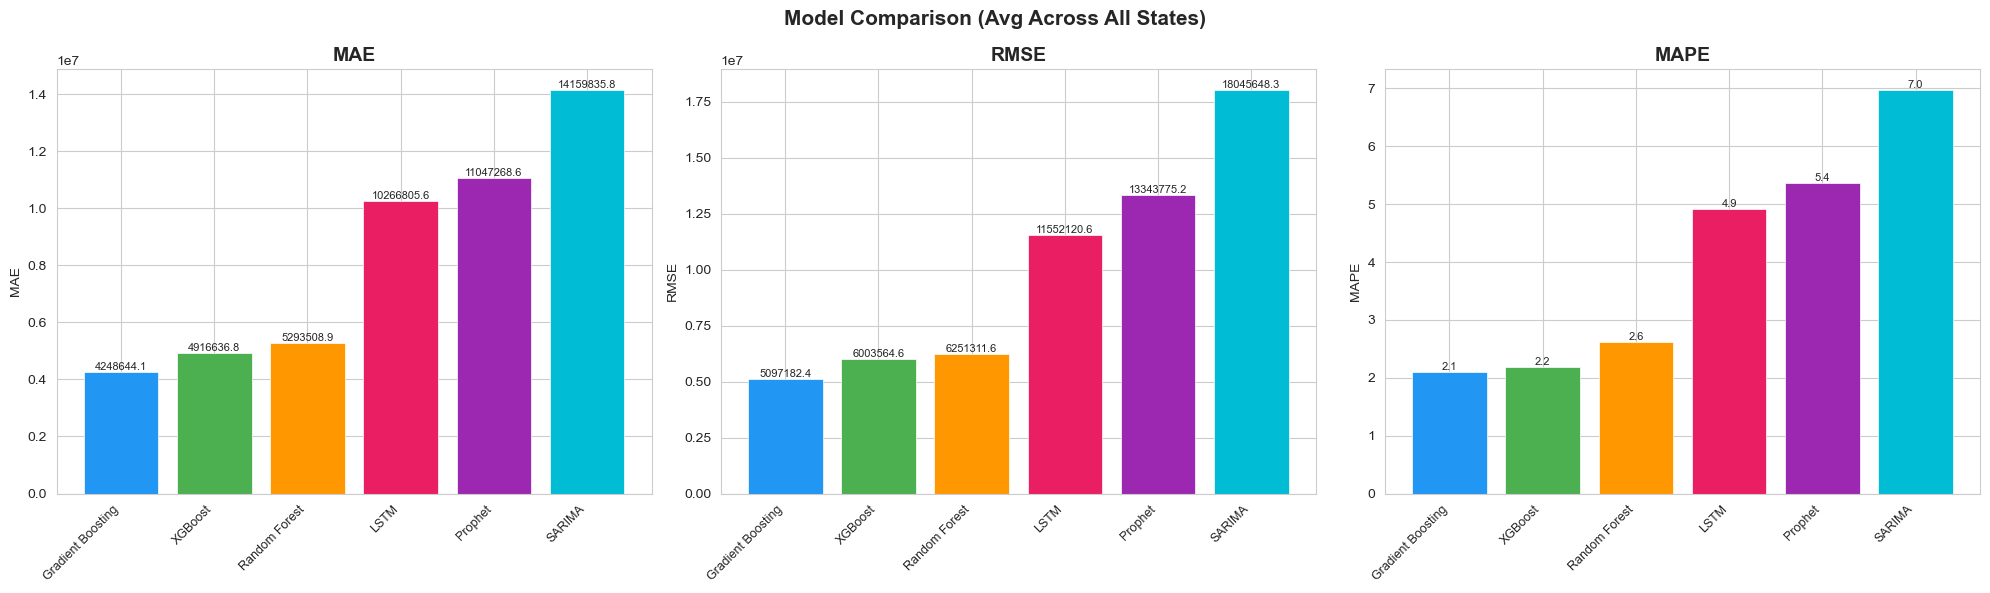

In [ ]:
# bar chart: MAE, RMSE, MAPE side by side
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
colors = ["#2196F3", "#4CAF50", "#FF9800", "#E91E63", "#9C27B0", "#00BCD4", "#795548"]

for i, metric in enumerate(["MAE", "RMSE", "MAPE"]):
    vals = comparison[metric]
    bars = axes[i].bar(range(len(vals)), vals.values,
                       color=colors[:len(vals)], edgecolor="white", lw=0.5)
    axes[i].set_xticks(range(len(vals)))
    axes[i].set_xticklabels(vals.index, rotation=45, ha="right", fontsize=9)
    axes[i].set_title(metric, fontweight="bold", fontsize=14)
    axes[i].set_ylabel(metric)

    for bar, v in zip(bars, vals.values):
        axes[i].text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                     f"{v:.1f}", ha="center", va="bottom", fontsize=8)

plt.suptitle("Model Comparison (Avg Across All States)", fontweight="bold", fontsize=15)
plt.tight_layout()
plt.savefig(f"{OUTPUT}/model_comparison_bar.png", dpi=150, bbox_inches="tight")
plt.show()

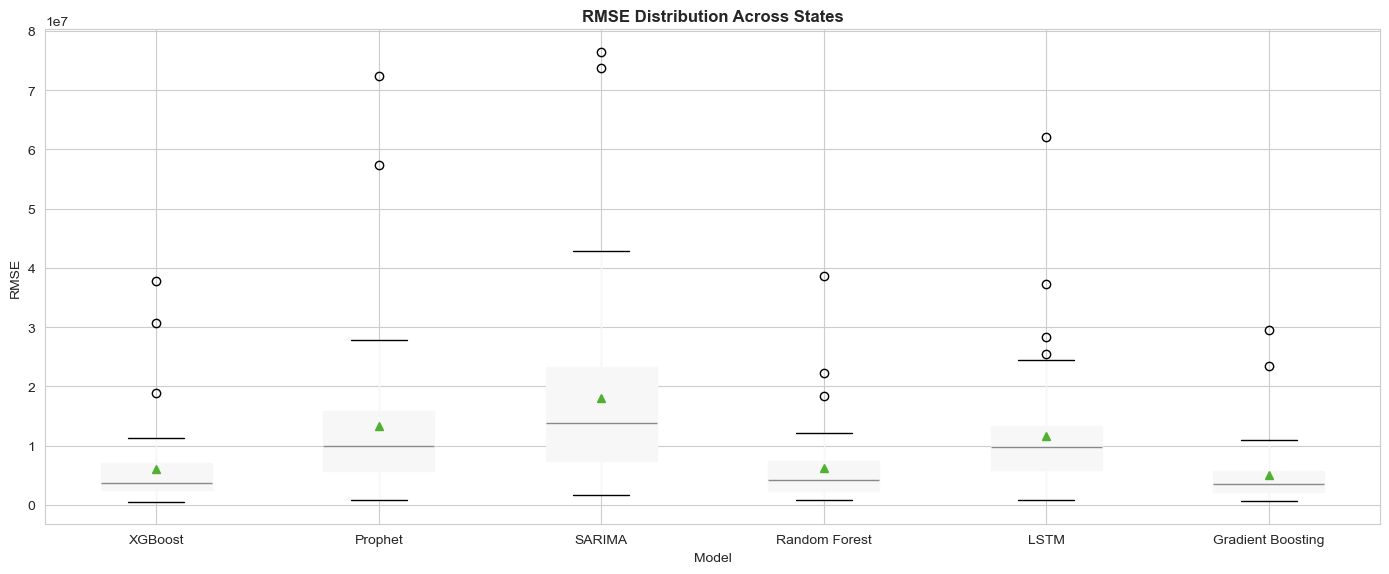

In [ ]:
# RMSE distribution across states (boxplot)
model_order = comparison.index.tolist()

fig, ax = plt.subplots(figsize=(14, 6))
bp = results_df.boxplot(
    column="RMSE", by="model", ax=ax,
    positions=[model_order.index(m) for m in results_df["model"].unique() if m in model_order],
    patch_artist=True, showmeans=True, return_type="dict",
)
ax.set_title("RMSE Distribution Across States", fontweight="bold")
ax.set_xlabel("Model")
ax.set_ylabel("RMSE")
plt.suptitle("")  # remove auto title
plt.tight_layout()
plt.savefig(f"{OUTPUT}/model_comparison_boxplot.png", dpi=150)
plt.show()

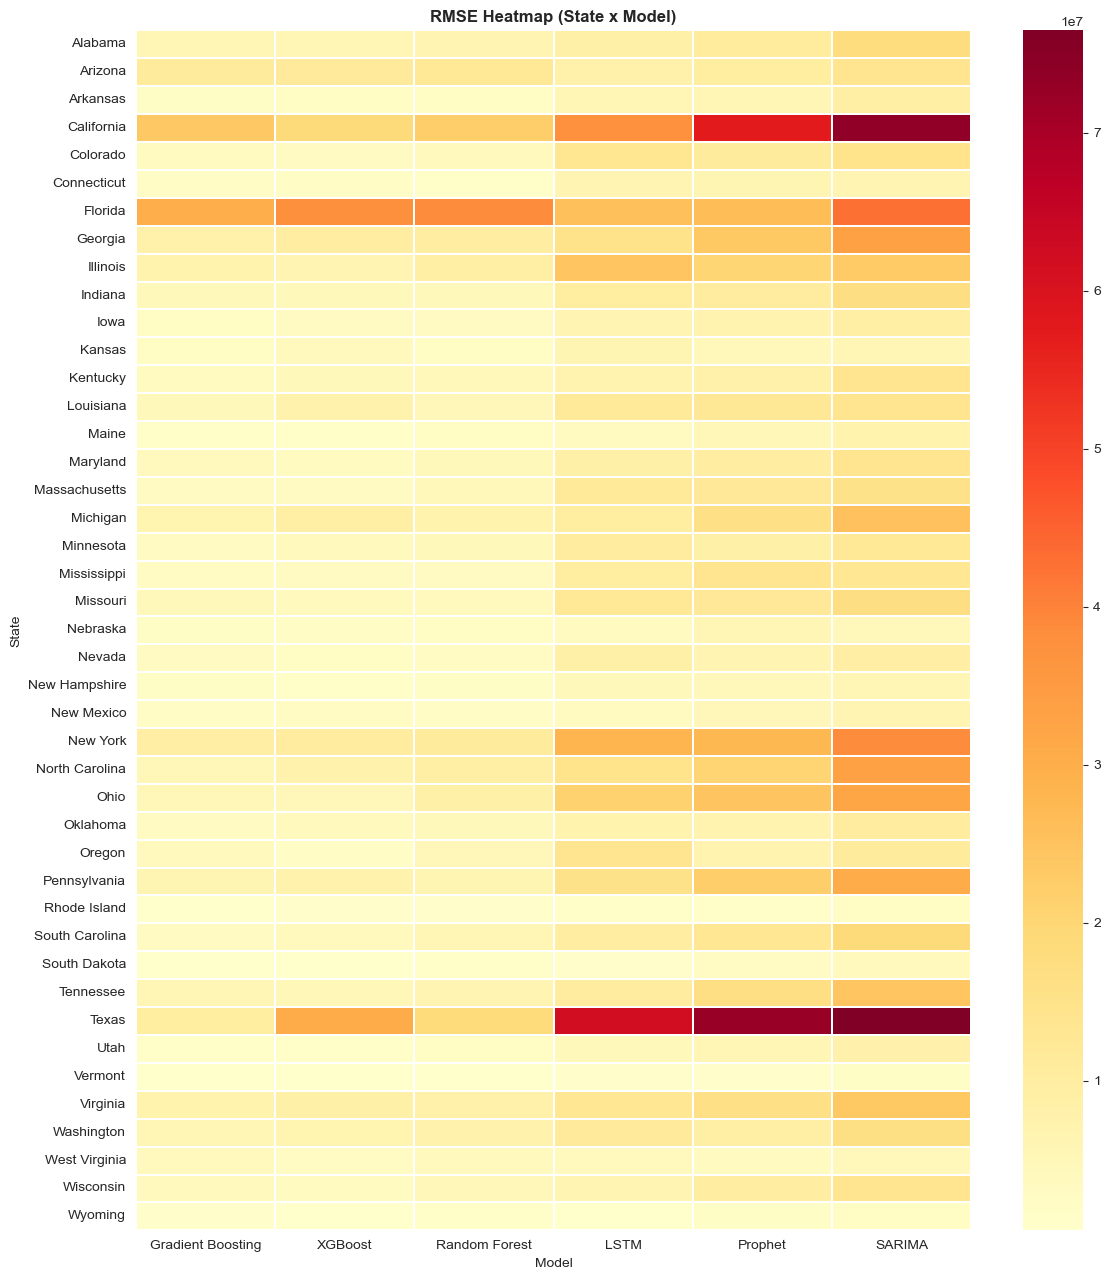

In [ ]:
# heatmap: RMSE for each state x model combination
pivot = results_df.pivot_table(index="state", columns="model", values="RMSE")
pivot = pivot[model_order]  # reorder columns by overall ranking

fig, ax = plt.subplots(figsize=(12, max(8, len(pivot) * 0.3)))
sns.heatmap(pivot, annot=False, cmap="YlOrRd", ax=ax, linewidths=0.3)
ax.set_title("RMSE Heatmap (State x Model)", fontweight="bold")
ax.set_xlabel("Model")
ax.set_ylabel("State")
plt.tight_layout()
plt.savefig(f"{OUTPUT}/model_rmse_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

Best Model Per State

In [ ]:
# for each state, find the model with the lowest RMSE
best_per_state = results_df.loc[results_df.groupby("state")["RMSE"].idxmin()]
best_per_state = best_per_state[["state", "model", "MAE", "RMSE", "MAPE"]].sort_values("state")

print("Best performing model per state:")
print(best_per_state.to_string(index=False))

# how many states does each model win?
win_counts = best_per_state["model"].value_counts()
print(f"\nModel win counts:")
for m, c in win_counts.items():
    print(f"  {m:25s} : {c} states")

Best performing model per state:
         state             model         MAE        RMSE  MAPE
       Alabama Gradient Boosting  4738604.64  5751872.18  2.34
       Arizona              LSTM  7126166.68  8061892.95  3.19
      Arkansas Gradient Boosting  1516603.90  1743868.74  1.38
    California           XGBoost 15026842.96 18867020.16  1.79
      Colorado           XGBoost  2530103.76  3182891.04  1.48
   Connecticut     Random Forest  1467907.21  1682785.86  1.66
       Florida              LSTM 20879684.47 25546983.81  2.78
       Georgia Gradient Boosting  6770764.45  7994439.24  1.82
      Illinois           XGBoost  5829445.11  6442759.05  1.85
       Indiana Gradient Boosting  3374329.55  4148183.19  1.54
          Iowa Gradient Boosting  2118045.65  2516539.96  1.84
        Kansas Gradient Boosting  1768842.35  2312948.89  1.93
      Kentucky Gradient Boosting  2990450.92  3462761.98  1.75
     Louisiana Gradient Boosting  3652465.81  4189489.12  2.03
         Maine        

Save Models & Results

In [ ]:
# save all fitted model objects to pickle files
for (model_name, state), model_obj in best_models.items():
    safe = f"{model_name}_{state}".replace(" ", "_").lower()
    path = f"{MODEL_DIR}/{safe}.pkl"
    with open(path, "wb") as f:
        pickle.dump(model_obj, f)

print(f"Saved {len(best_models)} model files to {MODEL_DIR}/")

# save result tables
results_df.to_csv(f"{OUTPUT}/all_model_results.csv", index=False)
comparison.to_csv(f"{OUTPUT}/model_comparison.csv")
print("Saved: all_model_results.csv, model_comparison.csv")

Saved 129 model files to output/models/
Saved: all_model_results.csv, model_comparison.csv


# Hyperparameter Tuning (All 7 Models)

In [ ]:
# all 7 models from the comparison table
models_to_tune = comparison.index.tolist()

print(f"Models to tune ({len(models_to_tune)}):")
for i, name in enumerate(models_to_tune, 1):
    row = comparison.loc[name]
    r, m, p = row["RMSE"], row["MAE"], row["MAPE"]
    print(f"  {i}. {name:25s}  RMSE={r:.2f}  MAE={m:.2f}  MAPE={p:.2f}%")

Models to tune (6):
  1. Gradient Boosting          RMSE=5097182.36  MAE=4248644.09  MAPE=2.10%
  2. XGBoost                    RMSE=6003564.60  MAE=4916636.81  MAPE=2.19%
  3. Random Forest              RMSE=6251311.58  MAE=5293508.91  MAPE=2.61%
  4. LSTM                       RMSE=11552120.56  MAE=10266805.63  MAPE=4.92%
  5. Prophet                    RMSE=13343775.18  MAE=11047268.59  MAPE=5.37%
  6. SARIMA                     RMSE=18045648.34  MAE=14159835.84  MAPE=6.98%


Tunning Configuration

In [ ]:
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

N_ITER  = 60
N_FOLDS = 5
tscv_tune = TimeSeriesSplit(n_splits=N_FOLDS)


def get_sklearn_config(name):
    """Return (estimator, param_distributions) for sklearn-style models."""

    if name == "XGBoost":
        from xgboost import XGBRegressor
        return XGBRegressor(random_state=42, verbosity=0), {
            "n_estimators": [100, 200, 300, 500],
            "max_depth": [3, 5, 7, 9],
            "learning_rate": [0.01, 0.03, 0.05, 0.1, 0.15],
            "subsample": [0.7, 0.8, 0.9, 1.0],
            "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
            "min_child_weight": [1, 3, 5, 7],
            "reg_alpha": [0, 0.01, 0.1, 1.0],
            "reg_lambda": [1.0, 5.0, 10.0],
        }

    elif name == "Random Forest":
        from sklearn.ensemble import RandomForestRegressor
        return RandomForestRegressor(random_state=42, n_jobs=-1), {
            "n_estimators": [100, 200, 300, 500],
            "max_depth": [5, 10, 15, 20, None],
            "min_samples_split": [2, 5, 10],
            "min_samples_leaf": [1, 2, 4, 8],
            "max_features": ["sqrt", "log2", 0.5, 0.8],
        }

    elif name == "LightGBM":
        import lightgbm as lgb
        return lgb.LGBMRegressor(random_state=42, verbose=-1), {
            "n_estimators": [100, 200, 300, 500],
            "max_depth": [3, 5, 7, 9, -1],
            "learning_rate": [0.01, 0.03, 0.05, 0.1],
            "subsample": [0.7, 0.8, 0.9, 1.0],
            "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
            "num_leaves": [15, 31, 63, 127],
            "min_child_samples": [5, 10, 20, 50],
            "reg_alpha": [0, 0.01, 0.1, 1.0],
            "reg_lambda": [0, 1.0, 5.0, 10.0],
        }

    elif name == "Gradient Boosting":
        from sklearn.ensemble import GradientBoostingRegressor
        return GradientBoostingRegressor(random_state=42), {
            "n_estimators": [100, 200, 300, 500],
            "max_depth": [3, 5, 7, 9],
            "learning_rate": [0.01, 0.03, 0.05, 0.1],
            "subsample": [0.7, 0.8, 0.9, 1.0],
            "min_samples_split": [2, 5, 10],
            "min_samples_leaf": [1, 2, 4],
            "max_features": ["sqrt", "log2", 0.5],
        }

    return None, None


print("Sklearn tuning configs ready.")

Sklearn tuning configs ready.


Custom Tuning Function (SARIMA, FbProphet, and LSTM need non-sklearn tuning loops)

In [ ]:
from itertools import product as iterprod


def tune_sarima_state(tr, te):
    """Grid search over ARIMA orders, pick by AIC."""
    from statsmodels.tsa.statespace.sarimax import SARIMAX

    y_train = tr.sort_values("Date")["Total"].values
    n_test  = len(te)

    orders   = [(1,1,0), (0,1,1), (1,1,1), (2,1,1), (2,1,2)]
    seasonal = [(0,1,0,52), (1,0,0,52), (0,1,1,52)]

    best_aic, best_fit, best_p = np.inf, None, None

    for o, s in iterprod(orders, seasonal):
        try:
            m = SARIMAX(y_train, order=o, seasonal_order=s,
                        enforce_stationarity=False, enforce_invertibility=False)
            fit = m.fit(disp=False, maxiter=300)
            if fit.aic < best_aic:
                best_aic = fit.aic
                best_fit = fit
                best_p = {"order": str(o), "seasonal": str(s), "AIC": round(fit.aic, 2)}
        except:
            continue

    if best_fit is None:
        raise ValueError("All SARIMA configs failed")

    preds = best_fit.forecast(steps=n_test)
    return preds, best_p


def tune_prophet_state(tr, te):
    """Grid search over Prophet hyperparameters, pick by RMSE."""
    import logging
    logging.getLogger("prophet").setLevel(logging.WARNING)
    logging.getLogger("cmdstanpy").setLevel(logging.WARNING)
    from prophet import Prophet

    train_p = tr[["Date", "Total"]].rename(columns={"Date": "ds", "Total": "y"})
    test_p  = te[["Date"]].rename(columns={"Date": "ds"})
    y_test  = te["Total"].values

    cps_vals  = [0.001, 0.01, 0.1, 0.5]
    sps_vals  = [0.01, 0.1, 1.0, 10.0]
    modes     = ["additive", "multiplicative"]

    best_rmse, best_preds, best_p = np.inf, None, None

    for cps, sps, mode in iterprod(cps_vals, sps_vals, modes):
        try:
            m = Prophet(yearly_seasonality=True, weekly_seasonality=False,
                        daily_seasonality=False, changepoint_prior_scale=cps,
                        seasonality_prior_scale=sps, seasonality_mode=mode)
            m.fit(train_p)
            preds = m.predict(test_p)["yhat"].values
            rmse  = np.sqrt(mean_squared_error(y_test, preds))
            if rmse < best_rmse:
                best_rmse  = rmse
                best_preds = preds
                best_p = {"cps": cps, "sps": sps, "mode": mode}
        except:
            continue

    if best_preds is None:
        raise ValueError("All Prophet configs failed")
    return best_preds, best_p


def tune_lstm_state(tr, te, fcols):
    """Try several LSTM architectures, pick by RMSE."""
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM as L, Dense, Dropout
    from tensorflow.keras.callbacks import EarlyStopping
    from tensorflow.keras.optimizers import Adam
    from sklearn.preprocessing import MinMaxScaler
    import tensorflow as tf
    tf.get_logger().setLevel("ERROR")

    X_tr = tr[fcols].values
    y_tr = tr["Total"].values.reshape(-1, 1)
    X_te = te[fcols].values
    y_te = te["Total"].values

    sc_x = MinMaxScaler().fit(X_tr)
    sc_y = MinMaxScaler().fit(y_tr)
    X_tr_s = sc_x.transform(X_tr).reshape(-1, 1, len(fcols))
    X_te_s = sc_x.transform(X_te).reshape(-1, 1, len(fcols))
    y_tr_s = sc_y.transform(y_tr).ravel()

    configs = [
        {"u1": 32,  "u2": 16, "lr": 0.001, "drop": 0.1},
        {"u1": 64,  "u2": 32, "lr": 0.001, "drop": 0.2},
        {"u1": 128, "u2": 64, "lr": 0.0005,"drop": 0.2},
        {"u1": 64,  "u2": 32, "lr": 0.01,  "drop": 0.1},
        {"u1": 128, "u2": 64, "lr": 0.001, "drop": 0.3},
        {"u1": 64,  "u2": 16, "lr": 0.005, "drop": 0.2},
    ]

    best_rmse, best_preds, best_p = np.inf, None, None

    for cfg in configs:
        try:
            model = Sequential([
                L(cfg["u1"], input_shape=(1, len(fcols)), return_sequences=True),
                Dropout(cfg["drop"]),
                L(cfg["u2"]),
                Dropout(cfg["drop"]),
                Dense(1),
            ])
            model.compile(optimizer=Adam(learning_rate=cfg["lr"]), loss="mse")
            es = EarlyStopping(patience=10, restore_best_weights=True, verbose=0)
            model.fit(X_tr_s, y_tr_s, epochs=50, batch_size=16,
                      validation_split=0.1, callbacks=[es], verbose=0)

            preds_s = model.predict(X_te_s, verbose=0).ravel()
            preds   = sc_y.inverse_transform(preds_s.reshape(-1, 1)).ravel()
            rmse    = np.sqrt(mean_squared_error(y_te, preds))

            if rmse < best_rmse:
                best_rmse  = rmse
                best_preds = preds
                best_p     = cfg
        except:
            continue

    if best_preds is None:
        raise ValueError("All LSTM configs failed")
    return best_preds, best_p


print("Custom tuning functions ready.")

Custom tuning functions ready.


Run Hyperparameter Tuning

In [ ]:
tuned_results = []
tuned_models  = {}
tuned_params  = {}

sep = "=" * 60

for model_name in models_to_tune:
    print(f"\n{sep}")
    print(f"  Tuning: {model_name}")
    print(f"{sep}")

    t0 = time.time()
    ok, fail = 0, 0

    estimator, param_dist = get_sklearn_config(model_name)
    is_sklearn = estimator is not None

    for state in states:
        tr = train_df[train_df["State"] == state]
        te = test_df[test_df["State"] == state]

        if len(tr) < 10 or len(te) == 0:
            continue

        try:
            if is_sklearn:
                X_tr, y_tr = tr[feature_cols], tr["Total"]
                X_te = te[feature_cols]

                search = RandomizedSearchCV(
                    estimator, param_dist,
                    n_iter=N_ITER,
                    scoring="neg_root_mean_squared_error",
                    cv=tscv_tune,
                    random_state=42,
                    n_jobs=-1,
                )
                search.fit(X_tr, y_tr)
                preds = search.best_estimator_.predict(X_te)
                tuned_models[(model_name, state)] = search.best_estimator_
                tuned_params[(model_name, state)] = search.best_params_

            elif model_name == "SARIMA":
                preds, bp = tune_sarima_state(tr, te)
                tuned_params[(model_name, state)] = bp

            elif model_name == "Prophet":
                preds, bp = tune_prophet_state(tr, te)
                tuned_params[(model_name, state)] = bp

            elif model_name == "LSTM":
                preds, bp = tune_lstm_state(tr, te, feature_cols)
                tuned_params[(model_name, state)] = bp

            else:
                continue

            metrics = evaluate(te["Total"].values, preds)
            metrics["model"] = model_name
            metrics["state"] = state
            tuned_results.append(metrics)
            ok += 1

        except Exception as e:
            print(f"  {state}: FAILED - {str(e)[:80]}")
            fail += 1

    elapsed = time.time() - t0
    print(f"  Done: {ok} ok / {fail} failed  ({elapsed:.1f}s)")

print(f"\nTuning complete. Total results: {len(tuned_results)}")


  Tuning: Gradient Boosting
  Done: 43 ok / 0 failed  (862.5s)

  Tuning: XGBoost
  Done: 43 ok / 0 failed  (650.5s)

  Tuning: Random Forest
  Done: 43 ok / 0 failed  (1231.3s)

  Tuning: LSTM
  Done: 43 ok / 0 failed  (1713.5s)

  Tuning: Prophet


02:38:15 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
02:38:15 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
02:38:16 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
02:38:16 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
02:38:17 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
02:38:18 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
02:38:18 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
02:38:19 - cm

  Done: 43 ok / 0 failed  (561.6s)

  Tuning: SARIMA
  Done: 43 ok / 0 failed  (2554.0s)

Tuning complete. Total results: 258


Tuned Model Result

In [ ]:
tuned_df = pd.DataFrame(tuned_results)

tuned_comparison = (
    tuned_df.groupby("model")[["MAE", "RMSE", "MAPE"]]
    .mean()
    .round(2)
    .sort_values("RMSE")
)

print("Tuned Model Metrics (avg across states, sorted by RMSE):")
tuned_comparison

Tuned Model Metrics (avg across states, sorted by RMSE):


,MAE,RMSE,MAPE
model,,,
XGBoost,5457260.90,6453528.20,2.54
LSTM,5747510.93,6682989.81,2.70
Gradient Boosting,5788317.61,6813835.83,2.70
Random Forest,6349636.81,7358612.84,3.06
Prophet,7825040.38,9585665.17,3.87
SARIMA,8547654.94,10616211.11,4.32


In [ ]:
# per-model breakdown
for name in models_to_tune:
    sub = tuned_df[tuned_df["model"] == name]
    if sub.empty:
        print(f"\n{name}: NO RESULTS (likely missing dependency)")
        continue

    avg_mae  = sub["MAE"].mean()
    avg_rmse = sub["RMSE"].mean()
    avg_mape = sub["MAPE"].mean()
    best_idx  = sub["RMSE"].idxmin()
    worst_idx = sub["RMSE"].idxmax()
    best_st   = sub.loc[best_idx, "state"]
    worst_st  = sub.loc[worst_idx, "state"]
    best_v    = sub["RMSE"].min()
    worst_v   = sub["RMSE"].max()

    print(f"\n {name} (tuned) ")
    print(f"  States trained : {len(sub)}")
    print(f"  Avg MAE        : {avg_mae:.2f}")
    print(f"  Avg RMSE       : {avg_rmse:.2f}")
    print(f"  Avg MAPE       : {avg_mape:.2f}%")
    print(f"  Best state     : {best_st} (RMSE={best_v:.2f})")
    print(f"  Worst state    : {worst_st} (RMSE={worst_v:.2f})")


 Gradient Boosting (tuned) 
  States trained : 43
  Avg MAE        : 5788317.61
  Avg RMSE       : 6813835.83
  Avg MAPE       : 2.70%
  Best state     : Vermont (RMSE=395560.71)
  Worst state    : Florida (RMSE=34517737.98)

 XGBoost (tuned) 
  States trained : 43
  Avg MAE        : 5457260.90
  Avg RMSE       : 6453528.20
  Avg MAPE       : 2.54%
  Best state     : South Dakota (RMSE=581124.92)
  Worst state    : Florida (RMSE=32250887.69)

 Random Forest (tuned) 
  States trained : 43
  Avg MAE        : 6349636.81
  Avg RMSE       : 7358612.84
  Avg MAPE       : 3.06%
  Best state     : Vermont (RMSE=518751.12)
  Worst state    : Florida (RMSE=38765474.64)

 LSTM (tuned) 
  States trained : 43
  Avg MAE        : 5747510.93
  Avg RMSE       : 6682989.81
  Avg MAPE       : 2.70%
  Best state     : Wyoming (RMSE=622069.00)
  Worst state    : California (RMSE=30189575.36)

 Prophet (tuned) 
  States trained : 43
  Avg MAE        : 7825040.38
  Avg RMSE       : 9585665.17
  Avg MAPE    

Before vs After Tuning

Compare baseline metrics against tuned metrics for all 7 models.

In [ ]:
rows = []
for name in models_to_tune:
    if name not in comparison.index or name not in tuned_comparison.index:
        continue

    base  = comparison.loc[name]
    tuned = tuned_comparison.loc[name]

    rmse_b = base["RMSE"]
    rmse_a = tuned["RMSE"]
    rmse_d = rmse_a - rmse_b
    rmse_p = (rmse_d / rmse_b) * 100

    rows.append({
        "Model": name,
        "RMSE (before)": rmse_b,
        "RMSE (after)":  rmse_a,
        "RMSE change":   round(rmse_d, 2),
        "RMSE % chg":    round(rmse_p, 2),
        "MAE (before)":  base["MAE"],
        "MAE (after)":   tuned["MAE"],
        "MAPE (before)": base["MAPE"],
        "MAPE (after)":  tuned["MAPE"],
    })

compare_df = pd.DataFrame(rows)
print("Before vs After Tuning (all 7 models):")
compare_df

Before vs After Tuning (all 7 models):


,Model,RMSE (before),RMSE (after),RMSE change,RMSE % chg,MAE (before),MAE (after),MAPE (before),MAPE (after)
0,Gradient Boosting,5097182.36,6813835.83,1716653.47,33.68,4248644.09,5788317.61,2.10,2.70
1,XGBoost,6003564.60,6453528.20,449963.60,7.49,4916636.81,5457260.90,2.19,2.54
2,Random Forest,6251311.58,7358612.84,1107301.26,17.71,5293508.91,6349636.81,2.61,3.06
3,LSTM,11552120.56,6682989.81,-4869130.75,-42.15,10266805.63,5747510.93,4.92,2.70
4,Prophet,13343775.18,9585665.17,-3758110.01,-28.16,11047268.59,7825040.38,5.37,3.87
5,SARIMA,18045648.34,10616211.11,-7429437.23,-41.17,14159835.84,8547654.94,6.98,4.32


Before vs After Comparison Plot

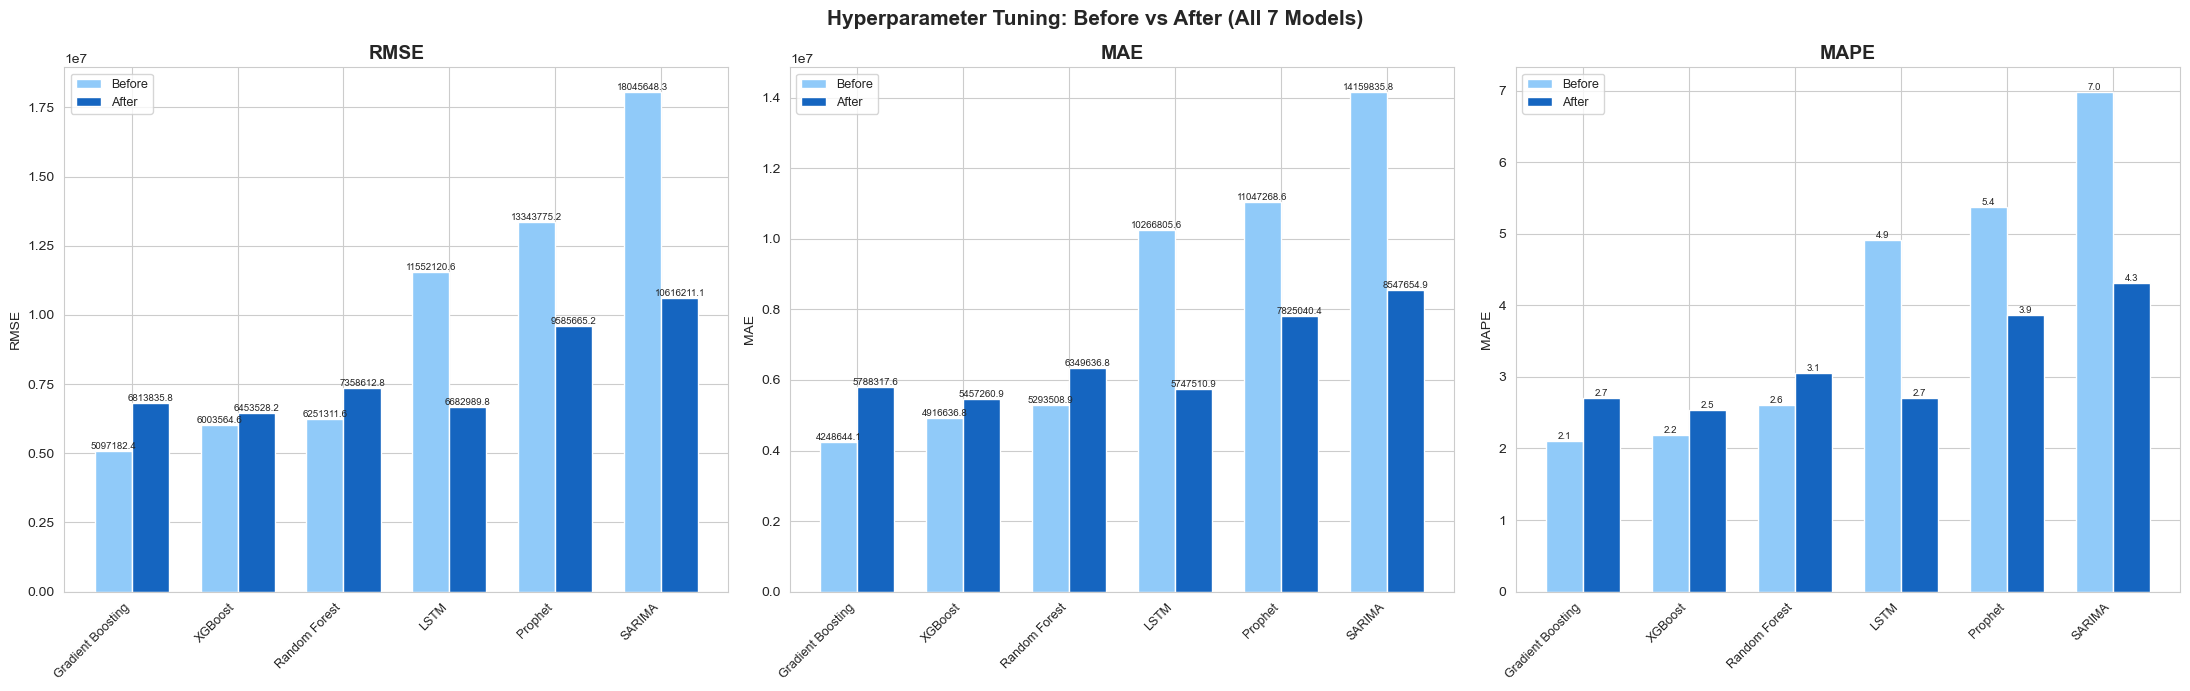

In [ ]:
n_models = len(compare_df)
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
x = np.arange(n_models)
w = 0.35

model_labels = compare_df["Model"].tolist()

for i, metric in enumerate(["RMSE", "MAE", "MAPE"]):
    before_col = f"{metric} (before)"
    after_col  = f"{metric} (after)"

    bv = compare_df[before_col].values
    av = compare_df[after_col].values

    axes[i].bar(x - w/2, bv, w, label="Before", color="#90CAF9", edgecolor="white")
    axes[i].bar(x + w/2, av, w, label="After",  color="#1565C0", edgecolor="white")

    axes[i].set_xticks(x)
    axes[i].set_xticklabels(model_labels, rotation=45, ha="right", fontsize=9)
    axes[i].set_title(metric, fontweight="bold", fontsize=14)
    axes[i].set_ylabel(metric)
    axes[i].legend(fontsize=9)

    for j, (b, a) in enumerate(zip(bv, av)):
        axes[i].text(j - w/2, b, f"{b:.1f}", ha="center", va="bottom", fontsize=7)
        axes[i].text(j + w/2, a, f"{a:.1f}", ha="center", va="bottom", fontsize=7)

plt.suptitle("Hyperparameter Tuning: Before vs After (All 7 Models)", fontweight="bold", fontsize=15)
plt.tight_layout()
plt.savefig(f"{OUTPUT}/tuning_before_after.png", dpi=150, bbox_inches="tight")
plt.show()

RMSE % Improvement

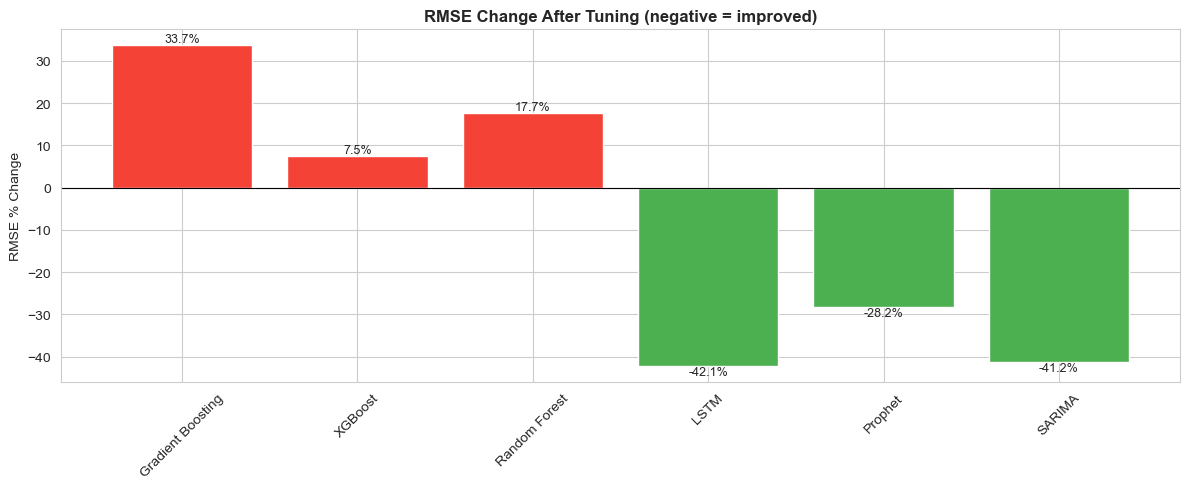

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))

pct = compare_df["RMSE % chg"].values
colors = ["#4CAF50" if v < 0 else "#F44336" for v in pct]

bars = ax.bar(model_labels, pct, color=colors, edgecolor="white")
ax.axhline(0, color="black", lw=0.8)
ax.set_ylabel("RMSE % Change")
ax.set_title("RMSE Change After Tuning (negative = improved)", fontweight="bold")
ax.tick_params(axis="x", rotation=45)

for bar, v in zip(bars, pct):
    va = "bottom" if v >= 0 else "top"
    ax.text(bar.get_x() + bar.get_width()/2, v, f"{v:.1f}%", ha="center", va=va, fontsize=9)

plt.tight_layout()
plt.savefig(f"{OUTPUT}/tuning_rmse_pct_change.png", dpi=150)
plt.show()

Best Hyperparameters (Sample)

In [ ]:
for name in models_to_tune:
    print(f"\n {name}")
    count = 0
    for (mn, st), params in tuned_params.items():
        if mn == name and count < 3:
            print(f"  {st}: {params}")
            count += 1
    if count == 0:
        print("  (no results)")


 Gradient Boosting
  Alabama: {'subsample': 0.7, 'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 7, 'learning_rate': 0.1}
  Arizona: {'subsample': 0.9, 'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 5, 'learning_rate': 0.1}
  Arkansas: {'subsample': 0.9, 'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 7, 'learning_rate': 0.1}

 XGBoost
  Alabama: {'subsample': 0.7, 'reg_lambda': 5.0, 'reg_alpha': 0, 'n_estimators': 500, 'min_child_weight': 5, 'max_depth': 7, 'learning_rate': 0.1, 'colsample_bytree': 0.7}
  Arizona: {'subsample': 0.9, 'reg_lambda': 1.0, 'reg_alpha': 0, 'n_estimators': 100, 'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 0.9}
  Arkansas: {'subsample': 1.0, 'reg_lambda': 1.0, 'reg_alpha': 0.1, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 7, 'learning_rate': 

Final Best Model

In [ ]:
winner = tuned_comparison.index[0]
w_row  = tuned_comparison.loc[winner]
w_rmse = w_row["RMSE"]
w_mae  = w_row["MAE"]
w_mape = w_row["MAPE"]

print(f"Best model after tuning: {winner}")
print(f"  Avg RMSE : {w_rmse:.2f}")
print(f"  Avg MAE  : {w_mae:.2f}")
print(f"  Avg MAPE : {w_mape:.2f}%")

# save tuned models
for (mn, st), model_obj in tuned_models.items():
    safe = f"tuned_{mn}_{st}".replace(" ", "_").lower()
    with open(f"{MODEL_DIR}/{safe}.pkl", "wb") as f:
        pickle.dump(model_obj, f)

tuned_df.to_csv(f"{OUTPUT}/tuned_results.csv", index=False)
compare_df.to_csv(f"{OUTPUT}/tuning_comparison.csv", index=False)
print(f"\nSaved {len(tuned_models)} tuned model files and result CSVs.")

Best model after tuning: XGBoost
  Avg RMSE : 6453528.20
  Avg MAE  : 5457260.90
  Avg MAPE : 2.54%

Saved 129 tuned model files and result CSVs.


# MLflow

Build Report Dict


In [ ]:
#  consolidate all results into a single report dictionary


report = {}

for name in models_to_tune:
    report[name] = {}

    # --- baseline metrics ---
    if name in comparison.index:
        b = comparison.loc[name]
        report[name]["baseline"] = {
            "avg_mae":  float(b["MAE"]),
            "avg_rmse": float(b["RMSE"]),
            "avg_mape": float(b["MAPE"]),
        }

    # --- tuned metrics ---
    if name in tuned_comparison.index:
        t = tuned_comparison.loc[name]
        report[name]["tuned"] = {
            "avg_mae":  float(t["MAE"]),
            "avg_rmse": float(t["RMSE"]),
            "avg_mape": float(t["MAPE"]),
        }

    # --- per-state baseline ---
    base_rows = results_df[results_df["model"] == name]
    report[name]["per_state_baseline"] = {
        row["state"]: {"MAE": row["MAE"], "RMSE": row["RMSE"], "MAPE": row["MAPE"]}
        for _, row in base_rows.iterrows()
    }

    # --- per-state tuned ---
    tuned_rows = tuned_df[tuned_df["model"] == name]
    report[name]["per_state_tuned"] = {
        row["state"]: {"MAE": row["MAE"], "RMSE": row["RMSE"], "MAPE": row["MAPE"]}
        for _, row in tuned_rows.iterrows()
    }

    # --- best hyperparameters (sample) ---
    state_params = {
        st: params
        for (mn, st), params in tuned_params.items()
        if mn == name
    }
    report[name]["best_params"] = state_params


# add metadata
report["_meta"] = {
    "n_states": len(states),
    "n_models": len(models_to_tune),
    "train_shape": list(train_df.shape),
    "test_shape": list(test_df.shape),
    "cutoff_date": str(cutoff_date),
    "feature_count": len(feature_cols),
    "features": feature_cols,
    "tune_n_iter": N_ITER,
    "tune_cv_folds": N_FOLDS,
}

# save to JSON
import json as _json

class NpEncoder(_json.JSONEncoder):
    def default(self, obj):
        import numpy as _np
        if isinstance(obj, (_np.integer,)): return int(obj)
        if isinstance(obj, (_np.floating,)): return float(obj)
        if isinstance(obj, _np.ndarray):    return obj.tolist()
        return super().default(obj)

with open(f"{OUTPUT}/report.json", "w") as f:
    _json.dump(report, f, indent=2, cls=NpEncoder)

print(f"Report dict built: {len(report) - 1} models + _meta")
print(f"Saved to {OUTPUT}/report.json")

# quick preview
for name in models_to_tune:
    entry = report[name]
    b_rmse = entry.get("baseline", {}).get("avg_rmse", "N/A")
    t_rmse = entry.get("tuned", {}).get("avg_rmse", "N/A")
    n_params = len(entry.get("best_params", {}))
    print(f"  {name:25s}  baseline_rmse={b_rmse}  tuned_rmse={t_rmse}  states_tuned={n_params}")

Report dict built: 6 models + _meta
Saved to output/report.json
  Gradient Boosting          baseline_rmse=5097182.36  tuned_rmse=6813835.83  states_tuned=43
  XGBoost                    baseline_rmse=6003564.6  tuned_rmse=6453528.2  states_tuned=43
  Random Forest              baseline_rmse=6251311.58  tuned_rmse=7358612.84  states_tuned=43
  LSTM                       baseline_rmse=11552120.56  tuned_rmse=6682989.81  states_tuned=43
  Prophet                    baseline_rmse=13343775.18  tuned_rmse=9585665.17  states_tuned=43
  SARIMA                     baseline_rmse=18045648.34  tuned_rmse=10616211.11  states_tuned=43


MLflow Setup

In [ ]:
%pip install mlflow

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import mlflow
import mlflow.sklearn
import mlflow.xgboost
import mlflow.lightgbm
from sklearn.model_selection import GridSearchCV
from mlflow.models import infer_signature

EXPERIMENT_NAME = "Sales_Forecasting_Models"

# set/create experiment
mlflow.set_experiment(EXPERIMENT_NAME)

print(f"MLflow tracking URI : {mlflow.get_tracking_uri()}")
print(f"Experiment          : {EXPERIMENT_NAME}")

MLflow tracking URI : sqlite:///D:/Projects/SalesForecasting/experiments/mlflow.db
Experiment          : Sales_Forecasting_Models


Log Baseline Runs

In [ ]:
for name in models_to_tune:
    entry = report.get(name, {})
    baseline = entry.get("baseline")
    if not baseline:
        print(f"  {name}: no baseline results, skipping")
        continue

    with mlflow.start_run(run_name=f"{name}_baseline"):
        # tags
        mlflow.set_tag("model_name", name)
        mlflow.set_tag("stage", "baseline")
        mlflow.set_tag("n_states", report["_meta"]["n_states"])

        # params
        mlflow.log_param("model", name)
        mlflow.log_param("stage", "baseline")
        mlflow.log_param("train_shape", str(report["_meta"]["train_shape"]))
        mlflow.log_param("test_shape", str(report["_meta"]["test_shape"]))
        mlflow.log_param("cutoff_date", report["_meta"]["cutoff_date"])
        mlflow.log_param("feature_count", report["_meta"]["feature_count"])

        # metrics
        mlflow.log_metric("avg_mae", baseline["avg_mae"])
        mlflow.log_metric("avg_rmse", baseline["avg_rmse"])
        mlflow.log_metric("avg_mape", baseline["avg_mape"])

        # per-state metrics (logged as individual metrics with state prefix)
        for state, m in entry.get("per_state_baseline", {}).items():
            safe_st = state.replace(" ", "_")
            mlflow.log_metric(f"rmse_{safe_st}", m["RMSE"])

    print(f"  Logged: {name} (baseline)")

print("Baseline runs logged.")

  Logged: Gradient Boosting (baseline)
  Logged: XGBoost (baseline)
  Logged: Random Forest (baseline)
  Logged: LSTM (baseline)
  Logged: Prophet (baseline)
  Logged: SARIMA (baseline)
Baseline runs logged.


Log Tuned Runs

In [ ]:
for name in models_to_tune:
    entry = report.get(name, {})
    tuned = entry.get("tuned")
    if not tuned:
        print(f"  {name}: no tuned results, skipping")
        continue

    with mlflow.start_run(run_name=f"{name}_tuned"):
        mlflow.set_tag("model_name", name)
        mlflow.set_tag("stage", "tuned")
        mlflow.set_tag("n_states", report["_meta"]["n_states"])
        mlflow.set_tag("tune_method",
                       "RandomizedSearchCV" if name in ["XGBoost","Random Forest","LightGBM","Gradient Boosting"]
                       else "custom_grid")

        # params
        mlflow.log_param("model", name)
        mlflow.log_param("stage", "tuned")
        mlflow.log_param("tune_n_iter", N_ITER)
        mlflow.log_param("tune_cv_folds", N_FOLDS)
        mlflow.log_param("feature_count", report["_meta"]["feature_count"])

        # log one sample of best_params (first state found)
        sample_params = {}
        for st, params in entry.get("best_params", {}).items():
            sample_params = params
            break
        for k, v in sample_params.items():
            mlflow.log_param(f"hp_{k}", v)

        # metrics
        mlflow.log_metric("avg_mae", tuned["avg_mae"])
        mlflow.log_metric("avg_rmse", tuned["avg_rmse"])
        mlflow.log_metric("avg_mape", tuned["avg_mape"])

        # improvement over baseline
        baseline = entry.get("baseline", {})
        if baseline:
            rmse_imp = baseline["avg_rmse"] - tuned["avg_rmse"]
            rmse_pct = (rmse_imp / baseline["avg_rmse"]) * 100
            mlflow.log_metric("rmse_improvement", round(rmse_imp, 2))
            mlflow.log_metric("rmse_improvement_pct", round(rmse_pct, 2))

        # per-state metrics
        for state, m in entry.get("per_state_tuned", {}).items():
            safe_st = state.replace(" ", "_")
            mlflow.log_metric(f"rmse_{safe_st}", m["RMSE"])

        # log model artifacts (pkl files)
        for (mn, st), model_obj in tuned_models.items():
            if mn == name:
                safe = f"tuned_{mn}_{st}".replace(" ", "_").lower()
                pkl_path = f"{MODEL_DIR}/{safe}.pkl"
                if os.path.exists(pkl_path):
                    mlflow.log_artifact(pkl_path, artifact_path="models")
                break  # log just one model file as sample

    print(f"  Logged: {name} (tuned)")

print("Tuned runs logged.")

  Logged: Gradient Boosting (tuned)
  Logged: XGBoost (tuned)
  Logged: Random Forest (tuned)
  Logged: LSTM (tuned)
  Logged: Prophet (tuned)
  Logged: SARIMA (tuned)
Tuned runs logged.


Log Comparison Artifacts

In [ ]:
# log CSVs and plots as a single summary run
with mlflow.start_run(run_name="experiment_summary"):
    mlflow.set_tag("stage", "summary")

    # log the full report JSON
    mlflow.log_artifact(f"{OUTPUT}/report.json")

    # log result CSVs
    for csv_name in ["all_model_results.csv", "tuned_results.csv",
                     "model_comparison.csv", "tuning_comparison.csv"]:
        path = f"{OUTPUT}/{csv_name}"
        if os.path.exists(path):
            mlflow.log_artifact(path, artifact_path="results")

    # log plots
    for img_name in ["model_comparison_bar.png", "model_comparison_boxplot.png",
                     "model_rmse_heatmap.png", "tuning_before_after.png",
                     "tuning_rmse_pct_change.png"]:
        path = f"{OUTPUT}/{img_name}"
        if os.path.exists(path):
            mlflow.log_artifact(path, artifact_path="plots")

    # log best overall model info
    mlflow.log_param("best_model", winner)
    mlflow.log_metric("best_rmse", w_rmse)
    mlflow.log_metric("best_mae", w_mae)
    mlflow.log_metric("best_mape", w_mape)

print("Summary run logged with all artifacts.")

Summary run logged with all artifacts.


View MLflow Runs

In [ ]:
# pull all runs from the experiment as a DataFrame
experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)
runs = mlflow.search_runs(experiment_ids=[experiment.experiment_id])

cols = ["run_id", "tags.model_name", "tags.stage",
        "metrics.avg_rmse", "metrics.avg_mae", "metrics.avg_mape"]
display_cols = [c for c in cols if c in runs.columns]

print(f"Total runs: {len(runs)}")
runs[display_cols].sort_values("metrics.avg_rmse")

Total runs: 39


,run_id,tags.model_name,tags.stage,metrics.avg_rmse,metrics.avg_mae,metrics.avg_mape
38,a7b365325ae94a23954123030460197b,Gradient Boosting,baseline,5097182.36,4248644.09,2.10
25,2cf9faa01f9d45c9879b0c22c400a33f,Gradient Boosting,baseline,5097182.36,4248644.09,2.10
12,4c816b2936344d39b8e6b58dcb77513e,Gradient Boosting,baseline,5097182.36,4248644.09,2.10
24,28df73aed7f34f4daeaf7ae336bfbf66,XGBoost,baseline,6003564.60,4916636.81,2.19
11,52ecb5ef75cd474fb541f2060f4c91d9,XGBoost,baseline,6003564.60,4916636.81,2.19
37,237a2268ef43427d95a4124e4b728c27,XGBoost,baseline,6003564.60,4916636.81,2.19
36,97e0b42e23674fb0b6b62c3af1199ab7,Random Forest,baseline,6251311.58,5293508.91,2.61
10,b5bbeb54c9d847258ccb20b5b3691570,Random Forest,baseline,6251311.58,5293508.91,2.61
23,dbd4a311cb8645a98a2a6a3ca15bbb54,Random Forest,baseline,6251311.58,5293508.91,2.61
5,78f65df0ddf54474b84e90254d635afe,XGBoost,tuned,6453528.20,5457260.90,2.54


Saves the Best Model

In [ ]:


import pickle

best_model_obj = None

# find the best tuned model object (winner was set earlier)
for (mn, st), obj in tuned_models.items():
    if mn == winner:
        best_model_obj = obj
        break

if best_model_obj is not None:
    with open("best_model.pkl", "wb") as f:
        pickle.dump(best_model_obj, f)
    print(f"Saved best model ({winner}) to best_model.pkl")
else:
    print(f"No sklearn model object found for {winner}. Saving report instead.")

# also save the full report for reference
import json as _json
with open("best_model_report.json", "w") as f:
    _json.dump({
        "best_model": winner,
        "avg_rmse": w_rmse,
        "avg_mae": w_mae,
        "avg_mape": w_mape,
    }, f, indent=2)
    print("Saved best_model_report.json")


Saved best model (XGBoost) to best_model.pkl
Saved best_model_report.json
